----
**Univariate feature-target analysis**
----

Связь каждого признака с `target_value` отдельно: корреляции, univariate ROC-AUC, mutual information.

In [1]:
%pip install -q pandas numpy matplotlib seaborn scipy scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, pearsonr, chi2_contingency
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

TARGET_COL = "target_value"
ID_COL = "front_id"
DATE_COL = "decision_day"

train_df = pd.read_csv(r"data\train_apps.csv")
y = train_df[TARGET_COL].astype(int)

feature_cols = [c for c in train_df.columns if c not in [TARGET_COL, ID_COL, DATE_COL]]
print(f"Rows: {len(train_df):,} | Features: {len(feature_cols)} | Target rate: {y.mean():.4f}")

Rows: 145,241 | Features: 25 | Target rate: 0.0609


----
**Доля пропусков по столбцам**
----

Строк: 145,241
Столбцов с пропусками: 20 / 28
Суммарно пропусков: 1,265,423


,column,missing_count,missing_pct,non_missing_pct
0,overdraft_app_term_max_360,139732,96.21%,3.79%
1,loan_rev_max_start_non_fin,132635,91.32%,8.68%
2,sum_deb_investment_90,128697,88.61%,11.39%
3,loan_rev_min_start_fin,124706,85.86%,14.14%
4,days_from_authperson_registration,78473,54.03%,45.97%
5,sum_deb_ul_30,61453,42.31%,57.69%
6,app_term_mean_360,55883,38.48%,61.52%
7,db_group_last,55883,38.48%,61.52%
8,sum_deb_ul_90,54111,37.26%,62.74%
9,corp_list,51188,35.24%,64.76%


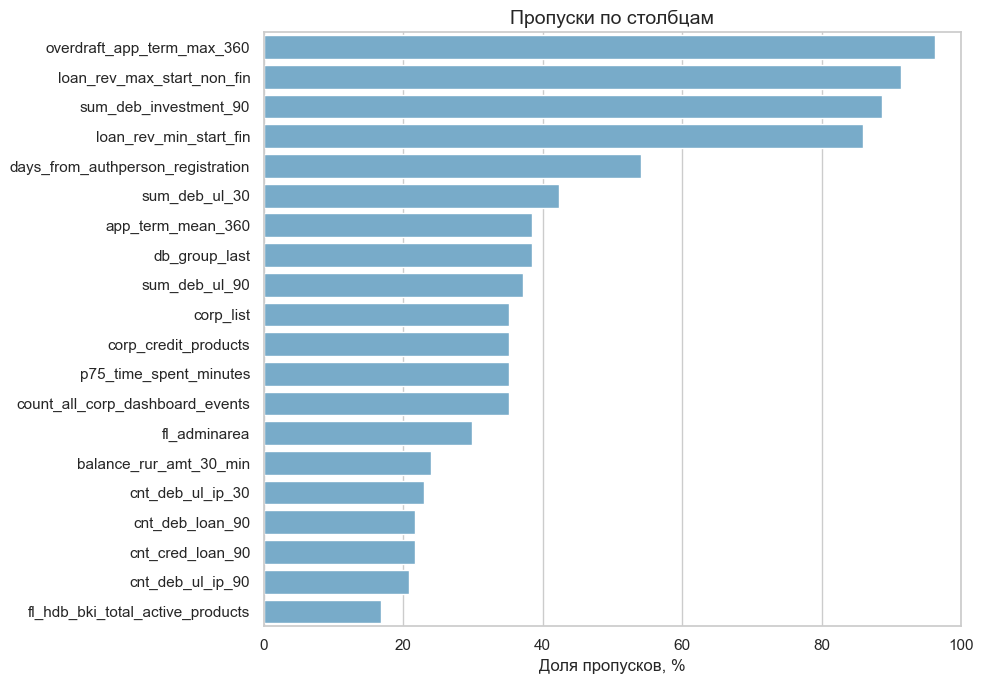

In [13]:
n_rows = len(train_df)

missing_df = (
    train_df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(
        missing_pct=lambda df: df["missing_count"] / n_rows * 100,
        non_missing_pct=lambda df: 100 - df["missing_pct"],
    )
    .sort_values("missing_pct", ascending=False)
    .reset_index()
    .rename(columns={"index": "column"})
)

print(f"Строк: {n_rows:,}")
print(f"Столбцов с пропусками: {(missing_df['missing_count'] > 0).sum()} / {len(missing_df)}")
print(f"Суммарно пропусков: {missing_df['missing_count'].sum():,}")

display(
    missing_df.style.format({
        "missing_pct": "{:.2f}%",
        "non_missing_pct": "{:.2f}%",
    })
)

cols_with_missing = missing_df.loc[missing_df["missing_count"] > 0]

if len(cols_with_missing) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(cols_with_missing))))
    sns.barplot(
        data=cols_with_missing,
        y="column",
        x="missing_pct",
        color="#6baed6",
        ax=ax,
    )
    ax.set_xlabel("Доля пропусков, %")
    ax.set_ylabel("")
    ax.set_title("Пропуски по столбцам")
    ax.set_xlim(0, min(100, cols_with_missing["missing_pct"].max() * 1.15))
    plt.tight_layout()
    plt.show()
else:
    print("Пропусков нет.")

In [6]:
def safe_univariate_auc(y_true, x):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan)
    valid = x.notna()
    if valid.sum() < 100 or x[valid].nunique() <= 1:
        return np.nan
    try:
        auc = roc_auc_score(y_true[valid], x[valid])
        return max(auc, 1 - auc)
    except ValueError:
        return np.nan


def cramers_v(x, y):
    codes = pd.Categorical(x.fillna("__MISSING__").astype(str)).codes
    contingency = pd.crosstab(codes, y)
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.values.sum()
    k = min(contingency.shape) - 1
    if k == 0 or n == 0:
        return np.nan
    return np.sqrt(chi2 / (n * k))


def cat_target_spread(x, y):
    rates = pd.DataFrame({"x": x.fillna("__MISSING__").astype(str), "y": y}).groupby("x")["y"].mean()
    return rates.max() - rates.min() if len(rates) > 1 else 0.0


rows = []

for col in feature_cols:
    s = train_df[col]
    row = {"feature": col, "dtype": str(s.dtype), "missing_pct": s.isna().mean() * 100}

    if pd.api.types.is_numeric_dtype(s):
        valid = s.replace([np.inf, -np.inf], np.nan).notna()
        x = s.replace([np.inf, -np.inf], np.nan)

        if valid.sum() >= 100 and x[valid].nunique() > 1:
            pearson_r, pearson_p = pearsonr(x[valid], y[valid])
            spearman_r, spearman_p = spearmanr(x[valid], y[valid])
            row["pearson"] = pearson_r
            row["spearman"] = spearman_r
            row["pearson_p"] = pearson_p
            row["spearman_p"] = spearman_p
        else:
            row["pearson"] = np.nan
            row["spearman"] = np.nan
            row["pearson_p"] = np.nan
            row["spearman_p"] = np.nan

        row["univariate_auc"] = safe_univariate_auc(y, x.fillna(x.median()))
        row["mutual_info"] = np.nan
        row["cramers_v"] = np.nan
        row["cat_target_spread"] = np.nan
        row["feature_type"] = "numeric"
    else:
        row["pearson"] = np.nan
        row["spearman"] = np.nan
        row["pearson_p"] = np.nan
        row["spearman_p"] = np.nan
        row["univariate_auc"] = safe_univariate_auc(
            y,
            pd.Series(pd.Categorical(s.fillna("__MISSING__").astype(str)).codes, index=s.index),
        )
        row["cramers_v"] = cramers_v(s, y)
        row["cat_target_spread"] = cat_target_spread(s, y)
        row["mutual_info"] = np.nan
        row["feature_type"] = "categorical"

    rows.append(row)

uni_df = pd.DataFrame(rows)

# mutual information for all features (numeric median-imputed, cats label-encoded)
X_mi = pd.DataFrame(index=train_df.index)
for col in feature_cols:
    s = train_df[col]
    if pd.api.types.is_numeric_dtype(s):
        X_mi[col] = s.replace([np.inf, -np.inf], np.nan).fillna(s.median())
    else:
        X_mi[col] = pd.Categorical(s.fillna("__MISSING__").astype(str)).codes

mi_values = mutual_info_classif(X_mi, y, discrete_features="auto", random_state=42)
uni_df["mutual_info"] = mi_values

uni_df["abs_pearson"] = uni_df["pearson"].abs()
uni_df["abs_spearman"] = uni_df["spearman"].abs()
uni_df["auc_strength"] = uni_df["univariate_auc"] - 0.5

uni_df["rank_spearman"] = uni_df["abs_spearman"].rank(ascending=False, method="min")
uni_df["rank_auc"] = uni_df["univariate_auc"].rank(ascending=False, method="min")
uni_df["rank_mi"] = uni_df["mutual_info"].rank(ascending=False, method="min")
uni_df["avg_rank"] = uni_df[["rank_spearman", "rank_auc", "rank_mi"]].mean(axis=1)

summary_df = uni_df.sort_values("avg_rank").reset_index(drop=True)

print("Топ-30 признаков по среднему рангу (Spearman | AUC | MI):")
display(
    summary_df.head(30)[
        [
            "feature",
            "feature_type",
            "missing_pct",
            "spearman",
            "univariate_auc",
            "mutual_info",
            "cramers_v",
            "cat_target_spread",
            "avg_rank",
        ]
    ]
)

Топ-30 признаков по среднему рангу (Spearman | AUC | MI):


,feature,feature_type,missing_pct,spearman,univariate_auc,mutual_info,cramers_v,cat_target_spread,avg_rank
0,cnt_deb_ul_ip_90,numeric,20.865320,0.136009,0.653256,0.013776,NaN,NaN,4.000000
1,cnt_cred_loan_90,numeric,21.659173,0.143118,0.632930,0.014878,NaN,NaN,4.666667
2,loan_rev_max_start_non_fin,numeric,91.320633,0.284811,0.589953,0.023789,NaN,NaN,5.000000
3,cnt_deb_ul_ip_30,numeric,22.977672,0.129848,0.644952,0.012505,NaN,NaN,5.333333
4,sum_deb_ul_90,numeric,37.256009,0.122818,0.628601,0.018012,NaN,NaN,6.000000
5,cnt_deb_loan_90,numeric,21.659173,0.120042,0.635374,0.017519,NaN,NaN,6.000000
6,count_all_corp_dashboard_events,numeric,35.243492,0.122549,0.629353,0.014168,NaN,NaN,7.333333
7,sum_deb_ul_30,numeric,42.311055,0.111502,0.611309,0.016635,NaN,NaN,9.000000
8,loan_rev_min_start_fin,numeric,85.861430,0.122507,0.558850,0.019329,NaN,NaN,9.333333
9,overdraft_limit_max,numeric,0.000000,0.112427,0.635694,0.010318,NaN,NaN,9.666667


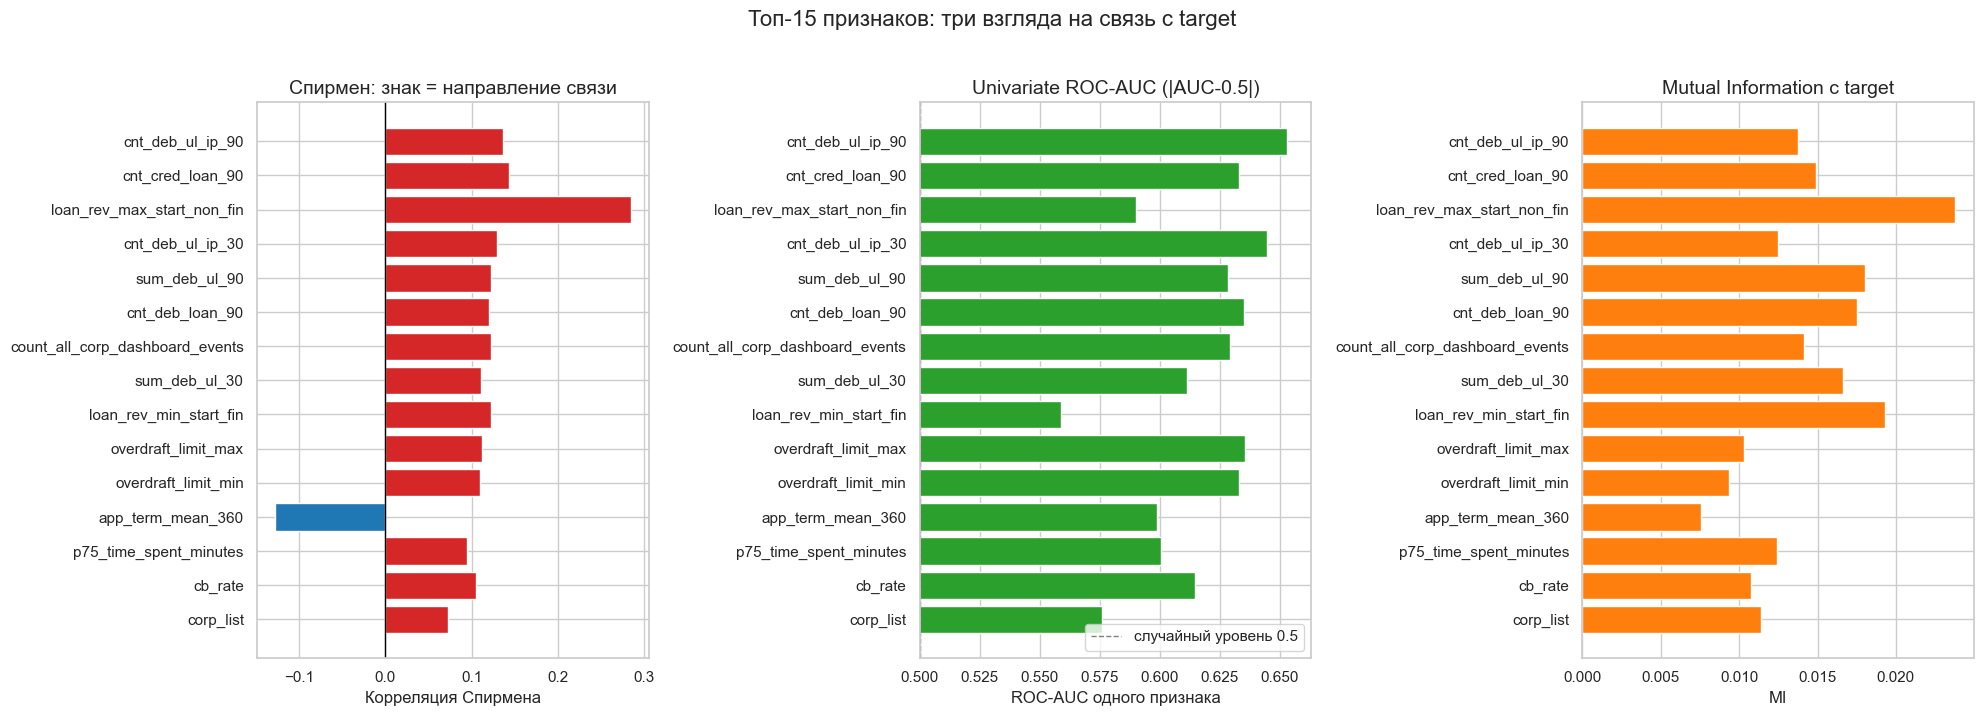

In [4]:
TOP_N = 15

plot_df = summary_df.head(TOP_N).iloc[::-1]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# 1) Spearman
spearman_plot = plot_df[["feature", "spearman"]].dropna()
colors = ["#d62728" if v > 0 else "#1f77b4" for v in spearman_plot["spearman"]]
axes[0].barh(spearman_plot["feature"], spearman_plot["spearman"], color=colors)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Спирмен: знак = направление связи")
axes[0].set_xlabel("Корреляция Спирмена")

# 2) Univariate AUC
auc_plot = plot_df[["feature", "univariate_auc"]].dropna()
axes[1].barh(auc_plot["feature"], auc_plot["univariate_auc"], color="#2ca02c")
axes[1].axvline(0.5, color="gray", linestyle="--", linewidth=1, label="случайный уровень 0.5")
axes[1].set_xlim(0.5, max(0.55, auc_plot["univariate_auc"].max() + 0.01))
axes[1].set_title("Univariate ROC-AUC (|AUC-0.5|)")
axes[1].set_xlabel("ROC-AUC одного признака")
axes[1].legend(loc="lower right")

# 3) Mutual information
mi_plot = plot_df[["feature", "mutual_info"]].dropna()
axes[2].barh(mi_plot["feature"], mi_plot["mutual_info"], color="#ff7f0e")
axes[2].set_title("Mutual Information с target")
axes[2].set_xlabel("MI")

plt.suptitle(f"Топ-{TOP_N} признаков: три взгляда на связь с target", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

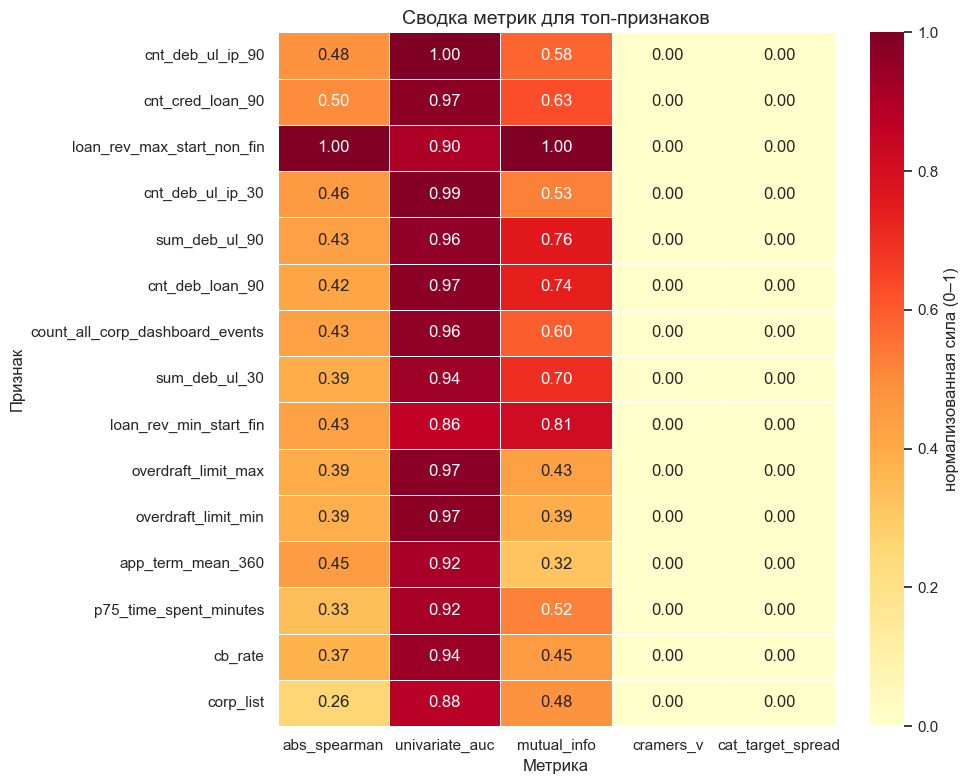

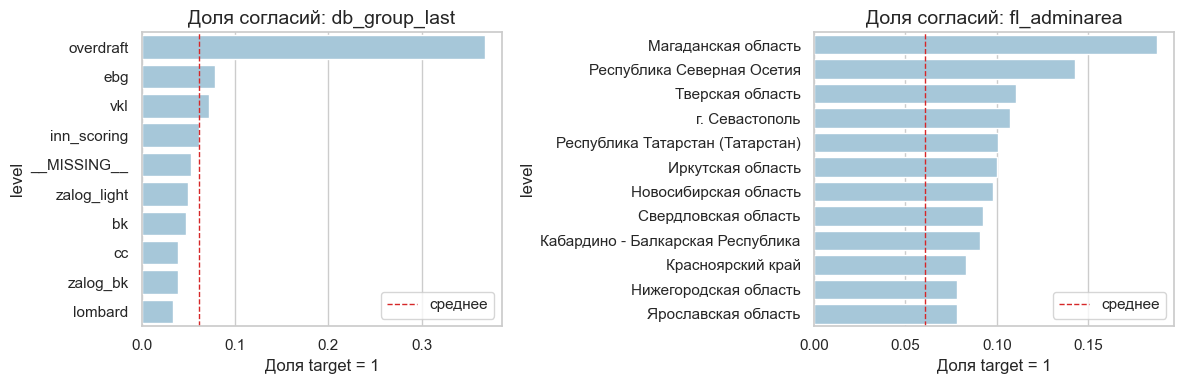

In [5]:
# Сводная heatmap: нормализованные метрики для топ-признаков
heat_cols = ["abs_spearman", "univariate_auc", "mutual_info", "cramers_v", "cat_target_spread"]
heat_df = summary_df.head(TOP_N).set_index("feature")[heat_cols].copy()

for col in heat_cols:
    col_max = heat_df[col].max()
    if col_max > 0:
        heat_df[col] = heat_df[col] / col_max

heat_df = heat_df.fillna(0.0)

plt.figure(figsize=(10, 8))
sns.heatmap(
    heat_df,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "нормализованная сила (0–1)"},
)
plt.title("Сводка метрик для топ-признаков")
plt.xlabel("Метрика")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

# Категориальные отдельно — доля согласий по уровням
cat_cols = summary_df[summary_df["feature_type"] == "categorical"]["feature"].tolist()

if cat_cols:
    fig, axes = plt.subplots(1, len(cat_cols), figsize=(6 * len(cat_cols), 4))
    if len(cat_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, cat_cols):
        tmp = (
            train_df[[col, TARGET_COL]]
            .assign(level=train_df[col].fillna("__MISSING__").astype(str))
            .groupby("level")[TARGET_COL]
            .agg(count="count", target_rate="mean")
            .sort_values("target_rate", ascending=False)
            .head(12)
        )
        sns.barplot(data=tmp.reset_index(), y="level", x="target_rate", color="#9ecae1", ax=ax)
        ax.axvline(y.mean(), color="#d62728", linestyle="--", linewidth=1, label="среднее")
        ax.set_title(f"Доля согласий: {col}")
        ax.set_xlabel("Доля target = 1")
        ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Категориальных признаков нет.")

----
**Модели на top-22 univariate признаках**
----

Берём 22 сильнейших признака по `avg_rank`, обучаем `XGBoost` / `CatBoost` / `LightGBM`, сравниваем **greedy blend** и **stacking (LogReg на OOF)**.

Note: you may need to restart the kernel to use updated packages.
Top-22 features | train=127,073 | valid=18,168
Обучение xgb_base...
  ROC=0.757500 | PR=0.316374
Обучение cat_base...
  ROC=0.755415 | PR=0.315967
Обучение lgbm_base...
  ROC=0.745808 | PR=0.304577

Greedy blend: ROC=0.760166 | PR=0.322779
Модели: ['xgb_base', 'cat_base', 'lgbm_base']


,step,model,weight_old,roc_auc
0,1,xgb_base,0.00,0.757500
1,2,cat_base,0.55,0.759887
2,3,lgbm_base,0.90,0.760166


Stacking (LogReg): ROC=0.759919 | PR=0.323097
Веса meta-модели:
  xgb_base: 2.4717
  cat_base: 2.7054
  lgbm_base: 1.5468

=== Сравнение ===


,method,roc_auc,pr_auc,logloss,pass_v2
3,greedy_blend,0.760166,0.322779,0.255888,False
4,stacking_logreg,0.759919,0.323097,0.253331,False
0,xgb_base,0.757500,0.316374,0.257469,False
1,cat_base,0.755415,0.315967,0.257029,False
2,lgbm_base,0.745808,0.304577,0.260944,False


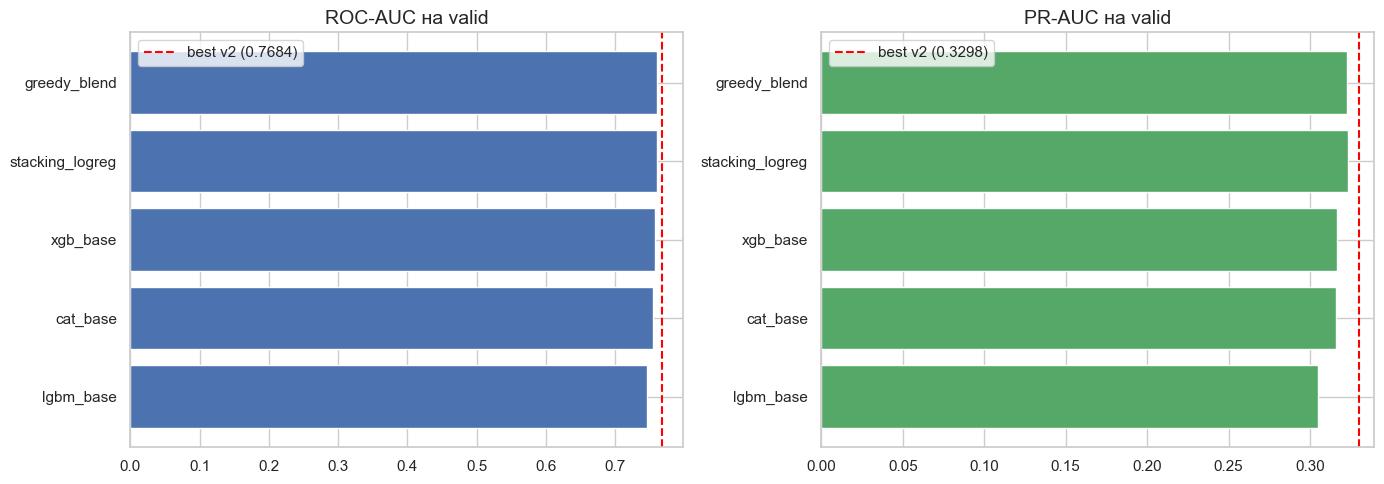

In [7]:
%pip install -q lightgbm xgboost catboost

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

RANDOM_STATE = 42
CUTOFF = "2025-02-01"
BEST_V2_ROC = 0.768359
BEST_V2_PR = 0.329786

TOP_22_FEATURES = [
    "cnt_deb_ul_ip_90",
    "cnt_cred_loan_90",
    "loan_rev_max_start_non_fin",
    "cnt_deb_ul_ip_30",
    "sum_deb_ul_90",
    "cnt_deb_loan_90",
    "count_all_corp_dashboard_events",
    "sum_deb_ul_30",
    "loan_rev_min_start_fin",
    "overdraft_limit_max",
    "overdraft_limit_min",
    "app_term_mean_360",
    "p75_time_spent_minutes",
    "cb_rate",
    "corp_list",
    "db_group_last",
    "offered_rate",
    "balance_rur_amt_30_min",
    "overdraft_app_term_max_360",
    "corp_credit_products",
    "loan_amount_last",
    "fl_adminarea",
]

CAT_COLS_TOP = ["db_group_last", "fl_adminarea"]
MODEL_NAMES = ["xgb_base", "cat_base", "lgbm_base"]


def prepare_top22_data(X_train, X_valid, model_name):
    X_tr = X_train.copy()
    X_va = X_valid.copy()

    numeric_cols = X_tr.select_dtypes(include="number").columns.tolist()
    X_tr[numeric_cols] = X_tr[numeric_cols].replace([np.inf, -np.inf], np.nan)
    X_va[numeric_cols] = X_va[numeric_cols].replace([np.inf, -np.inf], np.nan)

    cat_cols = [c for c in CAT_COLS_TOP if c in X_tr.columns]

    if model_name.startswith("cat"):
        for col in cat_cols:
            X_tr[col] = X_tr[col].fillna("__MISSING__").astype(str)
            X_va[col] = X_va[col].fillna("__MISSING__").astype(str)
        return X_tr, X_va, [X_tr.columns.get_loc(c) for c in cat_cols]

    if model_name.startswith("lgbm"):
        for col in cat_cols:
            X_tr[col] = X_tr[col].fillna("__MISSING__").astype("category")
            X_va[col] = X_va[col].fillna("__MISSING__").astype("category")
        return X_tr, X_va, cat_cols

    if model_name.startswith("xgb"):
        for col in cat_cols:
            combined = pd.concat([X_tr[col], X_va[col]], axis=0).fillna("__MISSING__").astype(str)
            mapping = {v: i for i, v in enumerate(combined.unique())}
            X_tr[col] = X_tr[col].fillna("__MISSING__").astype(str).map(mapping).astype(int)
            X_va[col] = X_va[col].fillna("__MISSING__").astype(str).map(mapping).fillna(-1).astype(int)
        return X_tr, X_va, None

    raise ValueError(model_name)


def make_model_top22(model_name):
    if model_name == "xgb_base":
        return XGBClassifier(
            objective="binary:logistic", eval_metric="auc", tree_method="hist",
            n_estimators=1000, learning_rate=0.035, max_depth=4, min_child_weight=8,
            subsample=0.85, colsample_bytree=0.85, reg_alpha=0.1, reg_lambda=6.0,
            random_state=RANDOM_STATE, n_jobs=-1,
        )
    if model_name == "cat_base":
        return CatBoostClassifier(
            iterations=1200, learning_rate=0.035, depth=6, l2_leaf_reg=8,
            loss_function="Logloss", eval_metric="AUC", random_seed=RANDOM_STATE,
            allow_writing_files=False, verbose=False, od_type="Iter", od_wait=100,
        )
    if model_name == "lgbm_base":
        return LGBMClassifier(
            objective="binary", n_estimators=1400, learning_rate=0.03, num_leaves=31,
            min_child_samples=60, subsample=0.85, colsample_bytree=0.85,
            reg_alpha=0.2, reg_lambda=6.0, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
        )
    raise ValueError(model_name)


def fit_predict_top22(model_name, X_train, y_train, X_valid, y_valid):
    X_tr, X_va, cat_features = prepare_top22_data(X_train, X_valid, model_name)
    model = make_model_top22(model_name)

    if model_name.startswith("cat"):
        model.fit(X_tr, y_train, cat_features=cat_features, eval_set=(X_va, y_valid), use_best_model=True)
    elif model_name.startswith("lgbm"):
        model.fit(X_tr, y_train, eval_set=[(X_va, y_valid)], categorical_feature=cat_features)
    else:
        model.fit(X_tr, y_train, eval_set=[(X_va, y_valid)], verbose=False)

    return model.predict_proba(X_va)[:, 1]


def eval_pred(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-6, 1 - 1e-6)
    return {
        "roc_auc": roc_auc_score(y_true, y_pred),
        "pr_auc": average_precision_score(y_true, y_pred),
        "logloss": log_loss(y_true, y_pred),
    }


def greedy_blend(y_true, predictions, max_models=8):
    scores = {c: roc_auc_score(y_true, predictions[c]) for c in predictions.columns}
    selected = [max(scores, key=scores.get)]
    current = predictions[selected[0]].values.copy()
    best_score = roc_auc_score(y_true, current)
    history = [{"step": 1, "model": selected[0], "weight_old": 0.0, "roc_auc": best_score}]
    remaining = [c for c in predictions.columns if c not in selected]

    while remaining and len(selected) < max_models:
        best_cand = best_w = best_pred = None
        local_best = best_score
        for cand in remaining:
            for w in np.linspace(0.1, 0.9, 17):
                blend = w * current + (1 - w) * predictions[cand].values
                sc = roc_auc_score(y_true, blend)
                if sc > local_best:
                    local_best, best_cand, best_pred, best_w = sc, cand, blend, w
        if best_cand is None:
            break
        selected.append(best_cand)
        remaining.remove(best_cand)
        current, best_score = best_pred, local_best
        history.append({"step": len(selected), "model": best_cand, "weight_old": best_w, "roc_auc": best_score})

    return current, selected, pd.DataFrame(history)


# --- split ---
data = train_df.copy()
data[DATE_COL] = pd.to_datetime(data[DATE_COL])

X = data[TOP_22_FEATURES].copy()
for col in CAT_COLS_TOP:
    X[col] = X[col].fillna("__MISSING__").astype(str)

y = data[TARGET_COL].astype(int)
train_mask = data[DATE_COL] < pd.Timestamp(CUTOFF)
valid_mask = ~train_mask

X_train, X_valid = X.loc[train_mask], X.loc[valid_mask]
y_train, y_valid = y.loc[train_mask], y.loc[valid_mask]

print(f"Top-22 features | train={len(X_train):,} | valid={len(X_valid):,}")

# --- 3 models ---
preds = pd.DataFrame(index=X_valid.index)
single_rows = []

for model_name in MODEL_NAMES:
    print(f"Обучение {model_name}...")
    pred = fit_predict_top22(model_name, X_train, y_train, X_valid, y_valid)
    preds[model_name] = pred
    metrics = eval_pred(y_valid, pred)
    single_rows.append({"method": model_name, **metrics})
    print(f"  ROC={metrics['roc_auc']:.6f} | PR={metrics['pr_auc']:.6f}")

# --- greedy blend ---
greedy_pred, selected_models, blend_hist = greedy_blend(y_valid, preds)
greedy_metrics = eval_pred(y_valid, greedy_pred)
print(f"\nGreedy blend: ROC={greedy_metrics['roc_auc']:.6f} | PR={greedy_metrics['pr_auc']:.6f}")
print("Модели:", selected_models)
display(blend_hist)

# --- stacking: LogReg on valid preds (in-sample meta; for honest OOF use folds) ---
stacker = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
stacker.fit(preds, y_valid)
stack_pred = stacker.predict_proba(preds)[:, 1]
stack_metrics = eval_pred(y_valid, stack_pred)

print(f"Stacking (LogReg): ROC={stack_metrics['roc_auc']:.6f} | PR={stack_metrics['pr_auc']:.6f}")
print("Веса meta-модели:")
for name, coef in zip(preds.columns, stacker.coef_[0]):
    print(f"  {name}: {coef:.4f}")

# --- compare ---
compare_df = pd.DataFrame(single_rows + [
    {"method": "greedy_blend", **greedy_metrics},
    {"method": "stacking_logreg", **stack_metrics},
])
compare_df["pass_v2"] = (compare_df["roc_auc"] >= BEST_V2_ROC) & (compare_df["pr_auc"] >= BEST_V2_PR)

print("\n=== Сравнение ===")
display(compare_df.sort_values("roc_auc", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_cmp = compare_df.sort_values("roc_auc", ascending=True)

axes[0].barh(plot_cmp["method"], plot_cmp["roc_auc"], color="#4C72B0")
axes[0].axvline(BEST_V2_ROC, color="red", linestyle="--", label=f"best v2 ({BEST_V2_ROC:.4f})")
axes[0].set_title("ROC-AUC на valid")
axes[0].legend()

axes[1].barh(plot_cmp["method"], plot_cmp["pr_auc"], color="#55A868")
axes[1].axvline(BEST_V2_PR, color="red", linestyle="--", label=f"best v2 ({BEST_V2_PR:.4f})")
axes[1].set_title("PR-AUC на valid")
axes[1].legend()

plt.tight_layout()
plt.show()

----
**Incremental XGBoost: top-5 → full feature set**
----

Добавляем признаки по одному (в порядке `avg_rank` из univariate-анализа) и смотрим, после какого добавления падает ROC-AUC / PR-AUC на valid.

Note: you may need to restart the kernel to use updated packages.
n= 5 | +sum_deb_ul_90                       | ROC=0.679957 (+nan) | PR=0.225865 | trees=542
n= 6 | +cnt_deb_loan_90                     | ROC=0.688574 (+0.008617) | PR=0.239022 | trees=669
n= 7 | +count_all_corp_dashboard_events     | ROC=0.695529 (+0.006955) | PR=0.240092 | trees=705
n= 8 | +sum_deb_ul_30                       | ROC=0.696028 (+0.000499) | PR=0.240270 | trees=622
n= 9 | +loan_rev_min_start_fin              | ROC=0.708311 (+0.012283) | PR=0.262471 | trees=1051
n=10 | +overdraft_limit_max                 | ROC=0.711939 (+0.003628) | PR=0.269482 | trees=635
n=11 | +overdraft_limit_min                 | ROC=0.712030 (+0.000091) | PR=0.268557 | trees=910
n=12 | +app_term_mean_360                   | ROC=0.727581 (+0.015552) | PR=0.283158 | trees=773
n=13 | +p75_time_spent_minutes              | ROC=0.727490 (-0.000092) | PR=0.282380 | trees=778
n=14 | +cb_rate                             | ROC=0.726838 (-0.00

,n_features,added_feature,roc_auc,delta_roc,delta_pr
12,17,offered_rate,0.725163,-0.003595,-0.001985
10,15,corp_list,0.724384,-0.002453,-0.002824
19,24,sum_deb_investment_90,0.762736,-0.000752,0.000697
9,14,cb_rate,0.726838,-0.000652,-0.000974
8,13,p75_time_spent_minutes,0.727490,-0.000092,-0.000777



Признаки, ухудшившие PR при добавлении:


,n_features,added_feature,roc_auc,delta_roc,delta_pr
10,15,corp_list,0.724384,-0.002453,-0.002824
12,17,offered_rate,0.725163,-0.003595,-0.001985
20,25,fl_hdb_bki_total_active_products,0.762824,0.000088,-0.001956
9,14,cb_rate,0.726838,-0.000652,-0.000974
6,11,overdraft_limit_min,0.712030,0.000091,-0.000925
8,13,p75_time_spent_minutes,0.727490,-0.000092,-0.000777


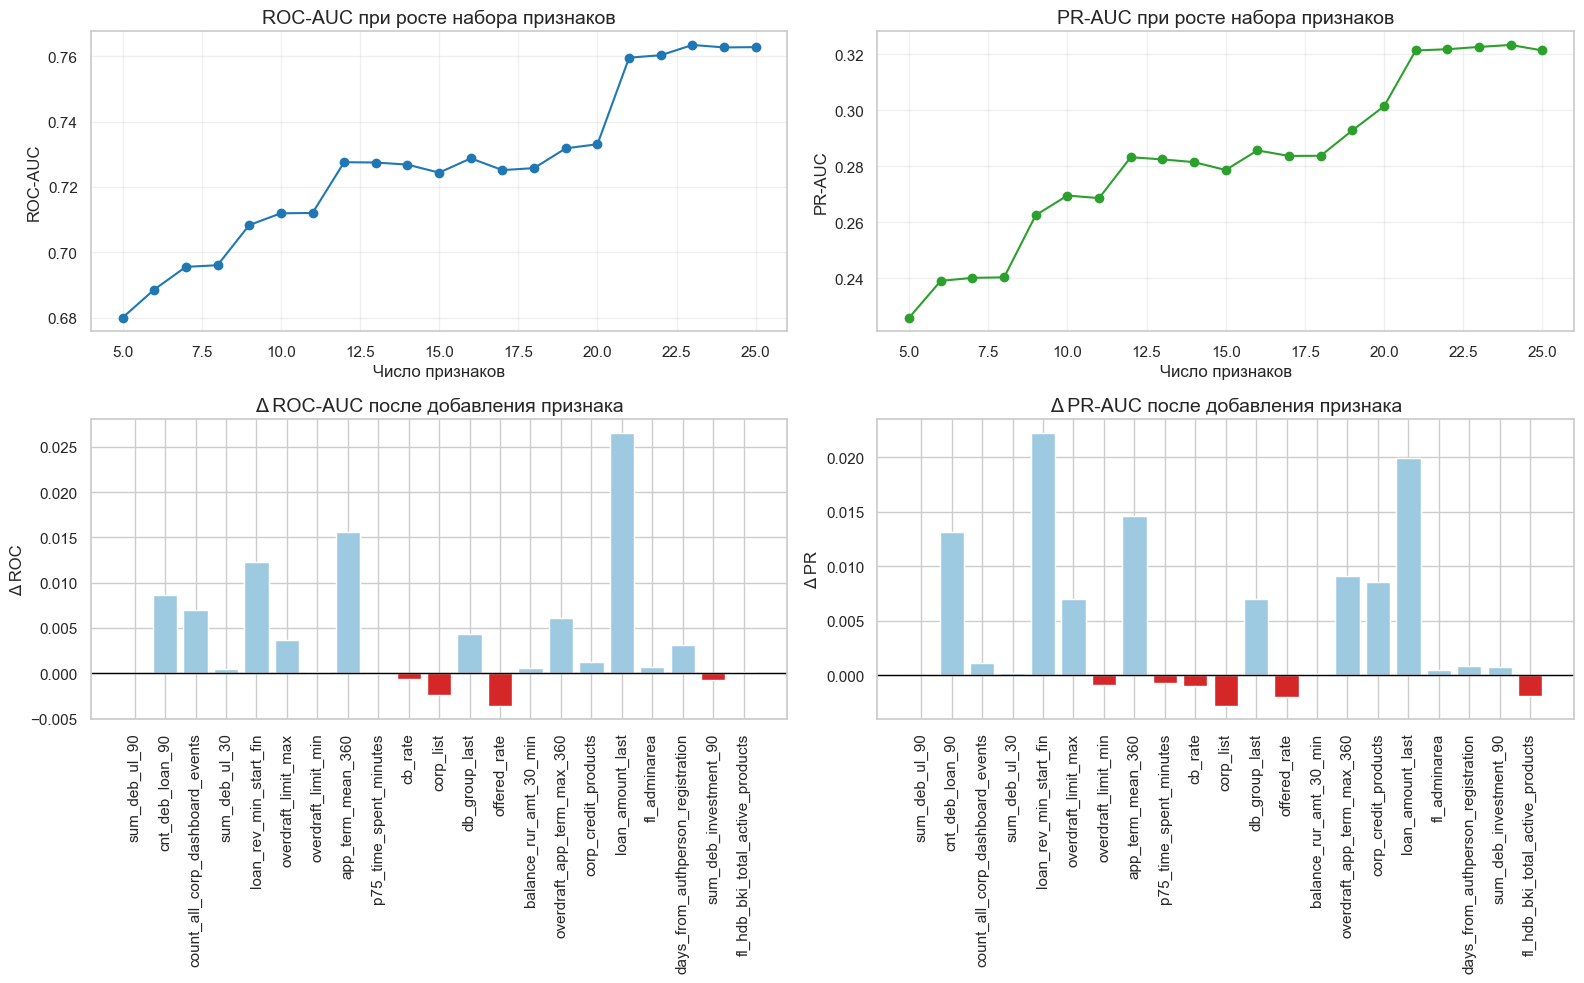

Лучший ROC: n=23 | ROC=0.763488 | последний добавленный: days_from_authperson_registration
Лучший PR:  n=24 | PR=0.323235 | последний добавленный: sum_deb_investment_90


In [8]:
%pip install -q xgboost

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

START_N = 5
CUTOFF = "2025-02-01"
RANDOM_STATE = 42
CAT_COLS_RAW = ["db_group_last", "fl_adminarea"]


def encode_xgb_features(X_train, X_valid):
    X_tr = X_train.copy()
    X_va = X_valid.copy()

    numeric_cols = X_tr.select_dtypes(include="number").columns.tolist()
    X_tr[numeric_cols] = X_tr[numeric_cols].replace([np.inf, -np.inf], np.nan)
    X_va[numeric_cols] = X_va[numeric_cols].replace([np.inf, -np.inf], np.nan)

    for col in CAT_COLS_RAW:
        if col not in X_tr.columns:
            continue
        combined = pd.concat([X_tr[col], X_va[col]], axis=0).fillna("__MISSING__").astype(str)
        mapping = {v: i for i, v in enumerate(combined.unique())}
        X_tr[col] = X_tr[col].fillna("__MISSING__").astype(str).map(mapping).astype(int)
        X_va[col] = X_va[col].fillna("__MISSING__").astype(str).map(mapping).fillna(-1).astype(int)

    return X_tr, X_va


def fit_xgb_incremental(X_train, y_train, X_valid, y_valid):
    X_tr, X_va = encode_xgb_features(X_train, X_valid)

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=10,
        subsample=0.85,
        colsample_bytree=0.8,
        reg_alpha=0.2,
        reg_lambda=8.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        early_stopping_rounds=80,
    )

    model.fit(
        X_tr,
        y_train,
        eval_set=[(X_va, y_valid)],
        verbose=False,
    )

    pred = model.predict_proba(X_va)[:, 1]
    return pred, model.best_iteration


# ranking from univariate block
if "summary_df" not in globals():
    raise RuntimeError("Сначала выполни ячейку с univariate-анализом (summary_df).")

feature_order = summary_df["feature"].tolist()
data = train_df.copy()
data[DATE_COL] = pd.to_datetime(data[DATE_COL])

train_mask = data[DATE_COL] < pd.Timestamp(CUTOFF)
valid_mask = ~train_mask
y_train = data.loc[train_mask, TARGET_COL].astype(int)
y_valid = data.loc[valid_mask, TARGET_COL].astype(int)

rows = []
prev_roc = None
prev_pr = None

for n_features in range(START_N, len(feature_order) + 1):
    cols = feature_order[:n_features]
    added_feature = cols[-1]

    X = data[cols].copy()
    for col in CAT_COLS_RAW:
        if col in X.columns:
            X[col] = X[col].fillna("__MISSING__").astype(str)

    X_train = X.loc[train_mask]
    X_valid = X.loc[valid_mask]

    pred, best_iter = fit_xgb_incremental(X_train, y_train, X_valid, y_valid)
    roc = roc_auc_score(y_valid, pred)
    pr = average_precision_score(y_valid, pred)

    delta_roc = np.nan if prev_roc is None else roc - prev_roc
    delta_pr = np.nan if prev_pr is None else pr - prev_pr

    rows.append({
        "n_features": n_features,
        "added_feature": added_feature,
        "roc_auc": roc,
        "pr_auc": pr,
        "delta_roc": delta_roc,
        "delta_pr": delta_pr,
        "best_iteration": best_iter,
        "hurts_roc": delta_roc < 0 if pd.notna(delta_roc) else False,
        "hurts_pr": delta_pr < 0 if pd.notna(delta_pr) else False,
    })

    prev_roc, prev_pr = roc, pr
    sign = "+" if delta_roc >= 0 or pd.isna(delta_roc) else ""
    print(
        f"n={n_features:2d} | +{added_feature:35s} | "
        f"ROC={roc:.6f} ({sign}{delta_roc:.6f}) | PR={pr:.6f} | trees={best_iter}"
    )

incr_df = pd.DataFrame(rows)

print("\nПризнаки, ухудшившие ROC при добавлении:")
display(
    incr_df[incr_df["hurts_roc"]]
    .sort_values("delta_roc")[["n_features", "added_feature", "roc_auc", "delta_roc", "delta_pr"]]
)

print("\nПризнаки, ухудшившие PR при добавлении:")
display(
    incr_df[incr_df["hurts_pr"]]
    .sort_values("delta_pr")[["n_features", "added_feature", "roc_auc", "delta_roc", "delta_pr"]]
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(incr_df["n_features"], incr_df["roc_auc"], marker="o", color="#1f77b4")
axes[0, 0].set_title("ROC-AUC при росте набора признаков")
axes[0, 0].set_xlabel("Число признаков")
axes[0, 0].set_ylabel("ROC-AUC")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(incr_df["n_features"], incr_df["pr_auc"], marker="o", color="#2ca02c")
axes[0, 1].set_title("PR-AUC при росте набора признаков")
axes[0, 1].set_xlabel("Число признаков")
axes[0, 1].set_ylabel("PR-AUC")
axes[0, 1].grid(True, alpha=0.3)

colors_roc = ["#d62728" if x else "#9ecae1" for x in incr_df["hurts_roc"].fillna(False)]
axes[1, 0].bar(incr_df["added_feature"], incr_df["delta_roc"].fillna(0), color=colors_roc)
axes[1, 0].axhline(0, color="black", linewidth=1)
axes[1, 0].set_title("Δ ROC-AUC после добавления признака")
axes[1, 0].set_ylabel("Δ ROC")
axes[1, 0].tick_params(axis="x", rotation=90)

colors_pr = ["#d62728" if x else "#9ecae1" for x in incr_df["hurts_pr"].fillna(False)]
axes[1, 1].bar(incr_df["added_feature"], incr_df["delta_pr"].fillna(0), color=colors_pr)
axes[1, 1].axhline(0, color="black", linewidth=1)
axes[1, 1].set_title("Δ PR-AUC после добавления признака")
axes[1, 1].set_ylabel("Δ PR")
axes[1, 1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

best_roc_row = incr_df.loc[incr_df["roc_auc"].idxmax()]
best_pr_row = incr_df.loc[incr_df["pr_auc"].idxmax()]

print(
    f"Лучший ROC: n={int(best_roc_row['n_features'])} | "
    f"ROC={best_roc_row['roc_auc']:.6f} | последний добавленный: {best_roc_row['added_feature']}"
)
print(
    f"Лучший PR:  n={int(best_pr_row['n_features'])} | "
    f"PR={best_pr_row['pr_auc']:.6f} | последний добавленный: {best_pr_row['added_feature']}"
)

----
**Календарные признаки из `decision_day`**
----

Связь target с **днём недели** и **неделей месяца** (1–4). Смотрим train целиком и отдельно valid-часть (`>= 2025-02-01`).

Базовая доля согласий: 0.0609

День недели (весь train):


,weekday_name,n,target_rate,share
2,Пн,30297,0.057828,0.208598
1,Вт,30847,0.061854,0.212385
5,Ср,29049,0.061551,0.200006
6,Чт,28954,0.063273,0.199351
3,Пт,22871,0.061388,0.157469
4,Сб,2346,0.059676,0.016152
0,Вс,877,0.025086,0.006038


Неделя месяца (весь train):


,week_of_month,n,target_rate,share
0,1,30511,0.055587,0.210072
1,2,31482,0.061718,0.216757
2,3,36881,0.061576,0.253930
3,4,46367,0.063321,0.319242


Cramér's V | weekday: 0.0140 | week_of_month: 0.0119


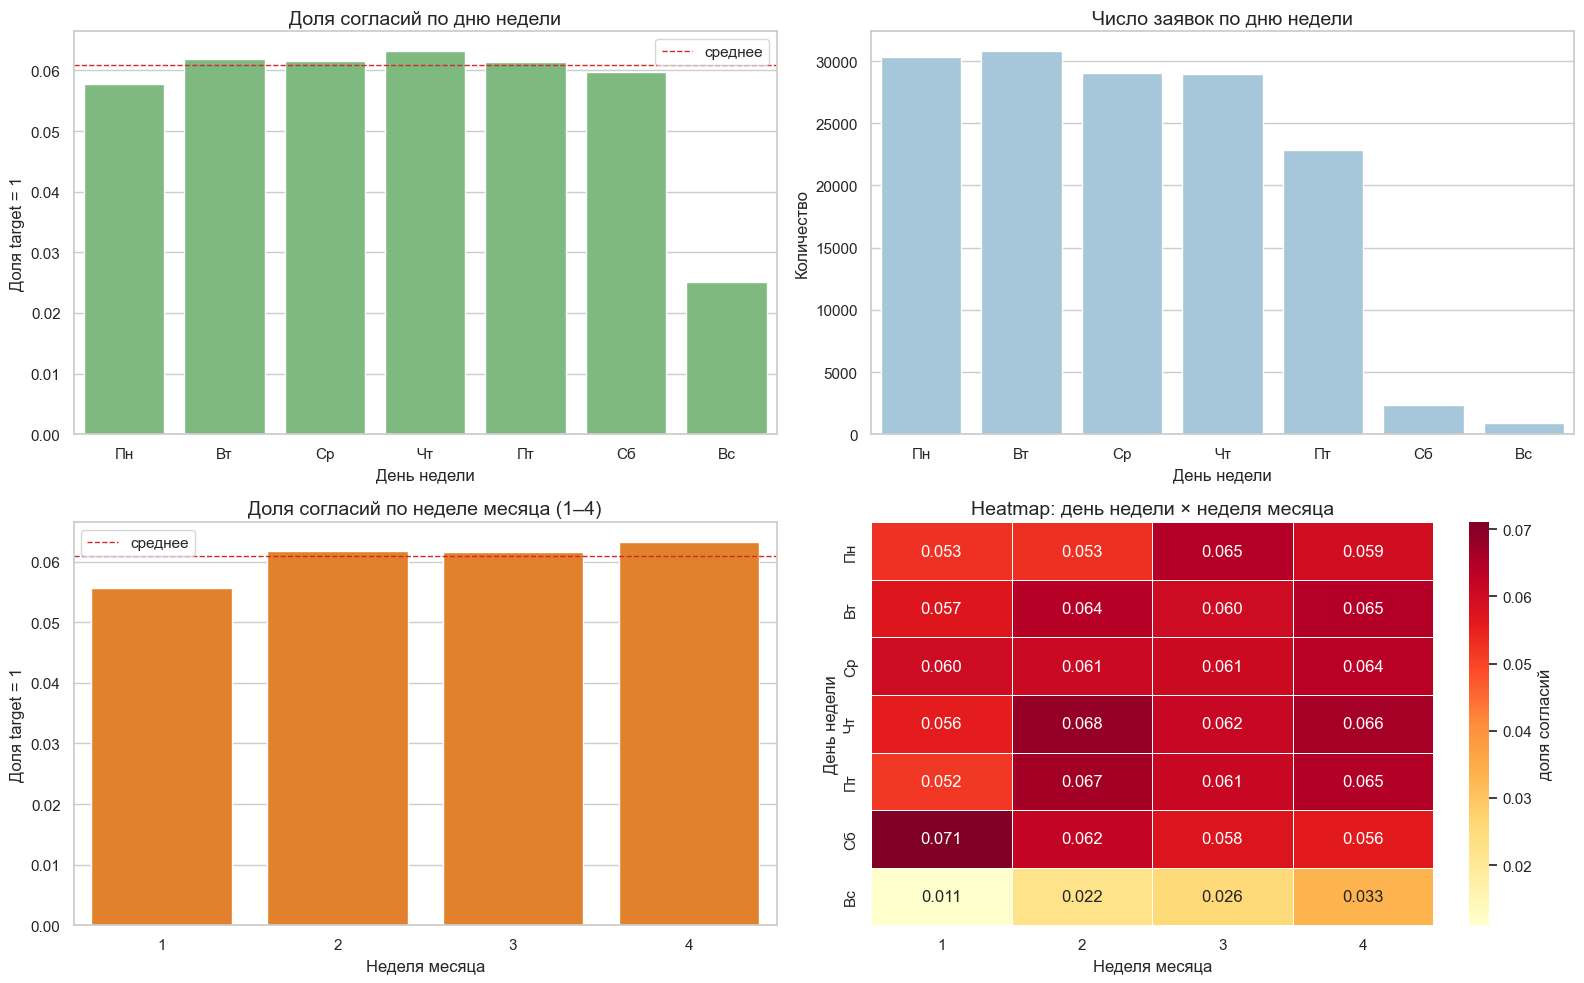

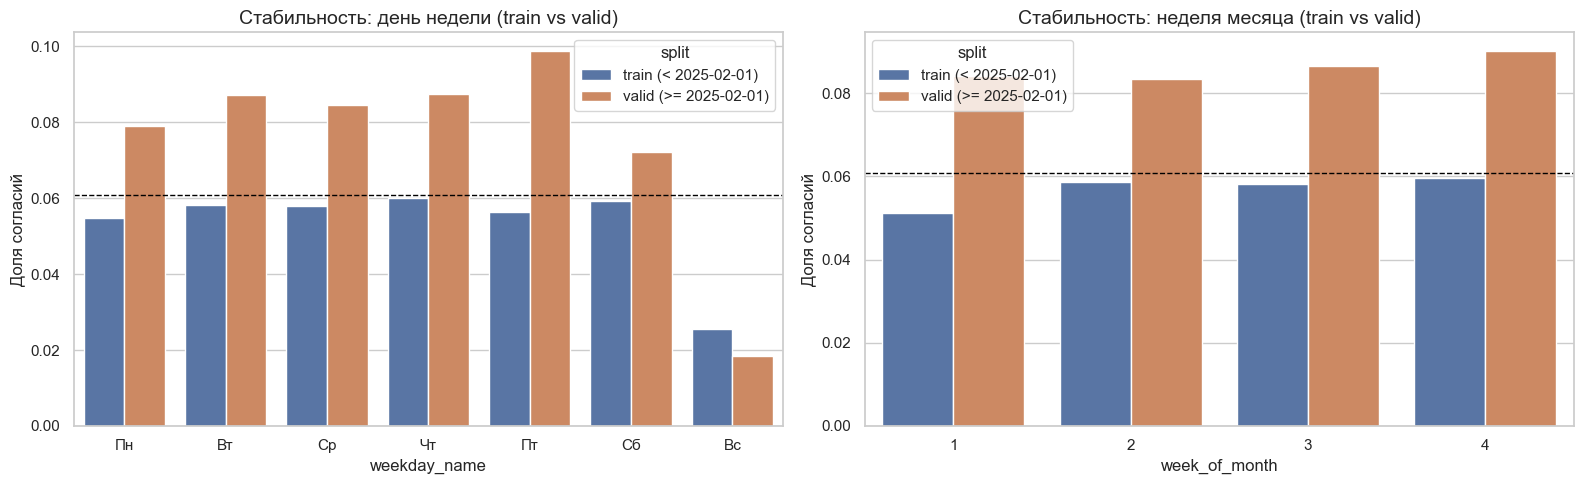

День недели: max Чт (0.0633) | min Вс (0.0251)
Неделя месяца: max неделя 4 (0.0633) | min неделя 1 (0.0556)


In [11]:
from scipy.stats import chi2_contingency

CUTOFF = pd.Timestamp("2025-02-01")
WEEKDAY_NAMES = {
    0: "Пн", 1: "Вт", 2: "Ср", 3: "Чт", 4: "Пт", 5: "Сб", 6: "Вс",
}


def week_of_month(date_series):
    day = date_series.dt.day
    return ((day - 1) // 7 + 1).clip(upper=4)


def target_profile(df, group_col, order=None):
    out = (
        df.groupby(group_col, observed=True)[TARGET_COL]
        .agg(n="count", target_rate="mean")
        .reset_index()
    )
    out["share"] = out["n"] / out["n"].sum()
    if order is not None:
        out[group_col] = pd.Categorical(out[group_col], categories=order, ordered=True)
        out = out.sort_values(group_col)
    return out


def cramers_v_from_table(table):
    chi2 = chi2_contingency(table)[0]
    n = table.values.sum()
    k = min(table.shape) - 1
    if n == 0 or k == 0:
        return np.nan
    return np.sqrt(chi2 / (n * k))


cal = train_df[[DATE_COL, TARGET_COL]].copy()
cal[DATE_COL] = pd.to_datetime(cal[DATE_COL])
cal["weekday"] = cal[DATE_COL].dt.weekday
cal["weekday_name"] = cal["weekday"].map(WEEKDAY_NAMES)
cal["week_of_month"] = week_of_month(cal[DATE_COL])
cal["split"] = np.where(cal[DATE_COL] < CUTOFF, "train (< 2025-02-01)", "valid (>= 2025-02-01)")

base_rate = cal[TARGET_COL].mean()

# --- tables (compact) ---
weekday_profile = target_profile(cal, "weekday_name", order=["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"])
wom_profile = target_profile(cal, "week_of_month", order=[1, 2, 3, 4])

print(f"Базовая доля согласий: {base_rate:.4f}")
print("\nДень недели (весь train):")
display(weekday_profile)

print("Неделя месяца (весь train):")
display(wom_profile)

# chi2 / Cramér's V
weekday_table = pd.crosstab(cal["weekday_name"], cal[TARGET_COL])
wom_table = pd.crosstab(cal["week_of_month"], cal[TARGET_COL])

print(
    f"Cramér's V | weekday: {cramers_v_from_table(weekday_table):.4f} | "
    f"week_of_month: {cramers_v_from_table(wom_table):.4f}"
)

# --- plots ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) weekday target rate
sns.barplot(
    data=weekday_profile,
    x="weekday_name",
    y="target_rate",
    color="#74c476",
    ax=axes[0, 0],
)
axes[0, 0].axhline(base_rate, color="#d62728", linestyle="--", linewidth=1, label="среднее")
axes[0, 0].set_title("Доля согласий по дню недели")
axes[0, 0].set_xlabel("День недели")
axes[0, 0].set_ylabel("Доля target = 1")
axes[0, 0].legend()

# 2) weekday volume
sns.barplot(
    data=weekday_profile,
    x="weekday_name",
    y="n",
    color="#9ecae1",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Число заявок по дню недели")
axes[0, 1].set_xlabel("День недели")
axes[0, 1].set_ylabel("Количество")

# 3) week of month target rate
sns.barplot(
    data=wom_profile,
    x="week_of_month",
    y="target_rate",
    color="#ff7f0e",
    ax=axes[1, 0],
)
axes[1, 0].axhline(base_rate, color="#d62728", linestyle="--", linewidth=1, label="среднее")
axes[1, 0].set_title("Доля согласий по неделе месяца (1–4)")
axes[1, 0].set_xlabel("Неделя месяца")
axes[1, 0].set_ylabel("Доля target = 1")
axes[1, 0].legend()

# 4) heatmap weekday x week_of_month
heat = (
    cal.groupby(["weekday_name", "week_of_month"], observed=True)[TARGET_COL]
    .mean()
    .unstack("week_of_month")
    .reindex(["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"])
)

sns.heatmap(
    heat,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=axes[1, 1],
    cbar_kws={"label": "доля согласий"},
)
axes[1, 1].set_title("Heatmap: день недели × неделя месяца")
axes[1, 1].set_xlabel("Неделя месяца")
axes[1, 1].set_ylabel("День недели")

plt.tight_layout()
plt.show()

# --- stability train vs valid ---
split_weekday = (
    cal.groupby(["split", "weekday_name"], observed=True)[TARGET_COL]
    .mean()
    .reset_index()
)
split_wom = (
    cal.groupby(["split", "week_of_month"], observed=True)[TARGET_COL]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=split_weekday,
    x="weekday_name",
    y=TARGET_COL,
    hue="split",
    order=["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"],
    ax=axes[0],
)
axes[0].axhline(base_rate, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Стабильность: день недели (train vs valid)")
axes[0].set_ylabel("Доля согласий")
axes[0].tick_params(axis="x", rotation=0)

sns.barplot(
    data=split_wom,
    x="week_of_month",
    y=TARGET_COL,
    hue="split",
    order=[1, 2, 3, 4],
    ax=axes[1],
)
axes[1].axhline(base_rate, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Стабильность: неделя месяца (train vs valid)")
axes[1].set_ylabel("Доля согласий")

plt.tight_layout()
plt.show()

# extremes
best_wd = weekday_profile.loc[weekday_profile["target_rate"].idxmax()]
worst_wd = weekday_profile.loc[weekday_profile["target_rate"].idxmin()]
best_wom = wom_profile.loc[wom_profile["target_rate"].idxmax()]
worst_wom = wom_profile.loc[wom_profile["target_rate"].idxmin()]

print(
    f"День недели: max {best_wd['weekday_name']} ({best_wd['target_rate']:.4f}) | "
    f"min {worst_wd['weekday_name']} ({worst_wd['target_rate']:.4f})"
)
print(
    f"Неделя месяца: max неделя {int(best_wom['week_of_month'])} ({best_wom['target_rate']:.4f}) | "
    f"min неделя {int(worst_wom['week_of_month'])} ({worst_wom['target_rate']:.4f})"
)

----
**XGBoost: исходные 25 признаков + `is_sunday`**
----

Только raw-колонки из `train_apps.csv` + флаг воскресенья из `decision_day`. Baseline (25 признаков) не переобучаем: ROC=0.762824, PR=0.321279.

In [ ]:
%pip install -q xgboost

from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier

CUTOFF = "2025-02-01"
RANDOM_STATE = 42
CAT_COLS_RAW = ["db_group_last", "fl_adminarea"]

BASELINE_ROC = 0.762824
BASELINE_PR = 0.321279


def encode_xgb_features(X_train, X_valid):
    X_tr = X_train.copy()
    X_va = X_valid.copy()

    numeric_cols = X_tr.select_dtypes(include="number").columns.tolist()
    X_tr[numeric_cols] = X_tr[numeric_cols].replace([np.inf, -np.inf], np.nan)
    X_va[numeric_cols] = X_va[numeric_cols].replace([np.inf, -np.inf], np.nan)

    for col in CAT_COLS_RAW:
        if col not in X_tr.columns:
            continue
        combined = pd.concat([X_tr[col], X_va[col]], axis=0).fillna("__MISSING__").astype(str)
        mapping = {v: i for i, v in enumerate(combined.unique())}
        X_tr[col] = X_tr[col].fillna("__MISSING__").astype(str).map(mapping).astype(int)
        X_va[col] = X_va[col].fillna("__MISSING__").astype(str).map(mapping).fillna(-1).astype(int)

    return X_tr, X_va


def fit_xgb_raw(X_train, y_train, X_valid, y_valid):
    X_tr, X_va = encode_xgb_features(X_train, X_valid)

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=10,
        subsample=0.85,
        colsample_bytree=0.8,
        reg_alpha=0.2,
        reg_lambda=8.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        early_stopping_rounds=80,
    )

    model.fit(
        X_tr,
        y_train,
        eval_set=[(X_va, y_valid)],
        verbose=False,
    )

    pred = model.predict_proba(X_va)[:, 1]
    return pred, model


# --- raw 25 + is_sunday ---
data = train_df.copy()
data[DATE_COL] = pd.to_datetime(data[DATE_COL])

raw_features = [c for c in train_df.columns if c not in [TARGET_COL, ID_COL, DATE_COL]]
X = data[raw_features].copy()
X["is_sunday"] = (data[DATE_COL].dt.weekday == 6).astype(int)

for col in CAT_COLS_RAW:
    if col in X.columns:
        X[col] = X[col].fillna("__MISSING__").astype(str)

y = data[TARGET_COL].astype(int)
train_mask = data[DATE_COL] < pd.Timestamp(CUTOFF)
valid_mask = ~train_mask

X_train = X.loc[train_mask]
X_valid = X.loc[valid_mask]
y_train = y.loc[train_mask]
y_valid = y.loc[valid_mask]

print(f"Признаки: raw={len(raw_features)} | +is_sunday={X.shape[1]}")
print(f"train={len(X_train):,} | valid={len(X_valid):,}")

pred, model = fit_xgb_raw(X_train, y_train, X_valid, y_valid)
roc = roc_auc_score(y_valid, pred)
pr = average_precision_score(y_valid, pred)

compare = pd.DataFrame([
    {
        "variant": "raw 25 (baseline, given)",
        "n_features": len(raw_features),
        "roc_auc": BASELINE_ROC,
        "pr_auc": BASELINE_PR,
        "delta_roc": 0.0,
        "delta_pr": 0.0,
    },
    {
        "variant": "raw 25 + is_sunday",
        "n_features": X.shape[1],
        "roc_auc": roc,
        "pr_auc": pr,
        "delta_roc": roc - BASELINE_ROC,
        "delta_pr": pr - BASELINE_PR,
    },
])

display(compare)

imp = (
    pd.Series(model.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .reset_index()
)
imp.columns = ["feature", "importance"]
imp["rank"] = np.arange(1, len(imp) + 1)

print(
    f"is_sunday: importance={imp.loc[imp['feature'] == 'is_sunday', 'importance'].iloc[0]:.6f} | "
    f"rank={int(imp.loc[imp['feature'] == 'is_sunday', 'rank'].iloc[0])}/{len(imp)}"
)
display(imp.head(15))

----
**XGBoost: raw 25 + `is_sunday` + `*_isna` (top-5 пропусков)**
----

Флаги пропусков для столбцов с наибольшей долей NaN.

In [14]:
%pip install -q xgboost

from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier

CUTOFF = "2025-02-01"
RANDOM_STATE = 42
CAT_COLS_RAW = ["db_group_last", "fl_adminarea"]

BASELINE_RAW_ROC = 0.762824
BASELINE_RAW_PR = 0.321279
BASELINE_SUNDAY_ROC = 0.764661
BASELINE_SUNDAY_PR = 0.324167

TOP5_ISNA_COLS = [
    "overdraft_app_term_max_360",
    "loan_rev_max_start_non_fin",
    "sum_deb_investment_90",
    "loan_rev_min_start_fin",
    "days_from_authperson_registration",
]


def encode_xgb_features(X_train, X_valid):
    X_tr = X_train.copy()
    X_va = X_valid.copy()

    numeric_cols = X_tr.select_dtypes(include="number").columns.tolist()
    X_tr[numeric_cols] = X_tr[numeric_cols].replace([np.inf, -np.inf], np.nan)
    X_va[numeric_cols] = X_va[numeric_cols].replace([np.inf, -np.inf], np.nan)

    for col in CAT_COLS_RAW:
        if col not in X_tr.columns:
            continue
        combined = pd.concat([X_tr[col], X_va[col]], axis=0).fillna("__MISSING__").astype(str)
        mapping = {v: i for i, v in enumerate(combined.unique())}
        X_tr[col] = X_tr[col].fillna("__MISSING__").astype(str).map(mapping).astype(int)
        X_va[col] = X_va[col].fillna("__MISSING__").astype(str).map(mapping).fillna(-1).astype(int)

    return X_tr, X_va


def fit_xgb_raw(X_train, y_train, X_valid, y_valid):
    X_tr, X_va = encode_xgb_features(X_train, X_valid)

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=10,
        subsample=0.85,
        colsample_bytree=0.8,
        reg_alpha=0.2,
        reg_lambda=8.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        early_stopping_rounds=80,
    )

    model.fit(
        X_tr,
        y_train,
        eval_set=[(X_va, y_valid)],
        verbose=False,
    )

    pred = model.predict_proba(X_va)[:, 1]
    return pred, model


def build_raw_augmented(data):
    raw_features = [c for c in train_df.columns if c not in [TARGET_COL, ID_COL, DATE_COL]]
    X = data[raw_features].copy()

    X["is_sunday"] = (data[DATE_COL].dt.weekday == 6).astype(int)

    for col in TOP5_ISNA_COLS:
        X[f"{col}_isna"] = X[col].isna().astype(int)

    for col in CAT_COLS_RAW:
        if col in X.columns:
            X[col] = X[col].fillna("__MISSING__").astype(str)

    return X, raw_features


# --- prepare data ---
data = train_df.copy()
data[DATE_COL] = pd.to_datetime(data[DATE_COL])

X, raw_features = build_raw_augmented(data)
y = data[TARGET_COL].astype(int)

train_mask = data[DATE_COL] < pd.Timestamp(CUTOFF)
valid_mask = ~train_mask

X_train = X.loc[train_mask]
X_valid = X.loc[valid_mask]
y_train = y.loc[train_mask]
y_valid = y.loc[valid_mask]

isna_cols = [f"{c}_isna" for c in TOP5_ISNA_COLS]

print(f"raw={len(raw_features)} | +is_sunday=1 | +isna={len(isna_cols)} | total={X.shape[1]}")
print(f"train={len(X_train):,} | valid={len(X_valid):,}")
print("isna flags:", isna_cols)

pred, model = fit_xgb_raw(X_train, y_train, X_valid, y_valid)
roc = roc_auc_score(y_valid, pred)
pr = average_precision_score(y_valid, pred)

compare = pd.DataFrame([
    {
        "variant": "raw 25 (baseline, given)",
        "n_features": 25,
        "roc_auc": BASELINE_RAW_ROC,
        "pr_auc": BASELINE_RAW_PR,
        "delta_roc_vs_raw": 0.0,
        "delta_pr_vs_raw": 0.0,
    },
    {
        "variant": "raw 25 + is_sunday (given)",
        "n_features": 26,
        "roc_auc": BASELINE_SUNDAY_ROC,
        "pr_auc": BASELINE_SUNDAY_PR,
        "delta_roc_vs_raw": BASELINE_SUNDAY_ROC - BASELINE_RAW_ROC,
        "delta_pr_vs_raw": BASELINE_SUNDAY_PR - BASELINE_RAW_PR,
    },
    {
        "variant": "raw 25 + is_sunday + top5_isna",
        "n_features": X.shape[1],
        "roc_auc": roc,
        "pr_auc": pr,
        "delta_roc_vs_raw": roc - BASELINE_RAW_ROC,
        "delta_pr_vs_raw": pr - BASELINE_RAW_PR,
    },
])

display(compare)

imp = (
    pd.Series(model.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .reset_index()
)
imp.columns = ["feature", "importance"]
imp["rank"] = np.arange(1, len(imp) + 1)

print("\nTop isna / calendar flags:")
display(imp[imp["feature"].isin(["is_sunday"] + isna_cols)].sort_values("importance", ascending=False))

display(imp.head(20))

Note: you may need to restart the kernel to use updated packages.
raw=25 | +is_sunday=1 | +isna=5 | total=31
train=127,073 | valid=18,168
isna flags: ['overdraft_app_term_max_360_isna', 'loan_rev_max_start_non_fin_isna', 'sum_deb_investment_90_isna', 'loan_rev_min_start_fin_isna', 'days_from_authperson_registration_isna']


,variant,n_features,roc_auc,pr_auc,delta_roc_vs_raw,delta_pr_vs_raw
0,"raw 25 (baseline, given)",25,0.762824,0.321279,0.000000,0.000000
1,raw 25 + is_sunday (given),26,0.764661,0.324167,0.001837,0.002888
2,raw 25 + is_sunday + top5_isna,31,0.763943,0.321301,0.001119,0.000022



Top isna / calendar flags:


,feature,importance,rank
0,overdraft_app_term_max_360_isna,0.136576,1
8,days_from_authperson_registration_isna,0.033232,9
11,loan_rev_min_start_fin_isna,0.028426,12
22,loan_rev_max_start_non_fin_isna,0.010553,23
28,sum_deb_investment_90_isna,0.005918,29
30,is_sunday,0.004655,31


,feature,importance,rank
0,overdraft_app_term_max_360_isna,0.136576,1
1,loan_rev_max_start_non_fin,0.133594,2
2,overdraft_app_term_max_360,0.087273,3
3,sum_deb_ul_30,0.073894,4
4,cb_rate,0.054100,5
5,cnt_deb_loan_90,0.047720,6
6,loan_rev_min_start_fin,0.045715,7
7,sum_deb_ul_90,0.044603,8
8,days_from_authperson_registration_isna,0.033232,9
9,loan_amount_last,0.031785,10


----
**Интерпретация модели: SHAP, importance, FP vs TP**
----

XGB на `raw + is_sunday + top5_isna`. Анализ valid: глобальная важность, permutation, SHAP, профиль ошибок FP.

Note: you may need to restart the kernel to use updated packages.
valid=18,168 | features=31 | ROC=0.763943


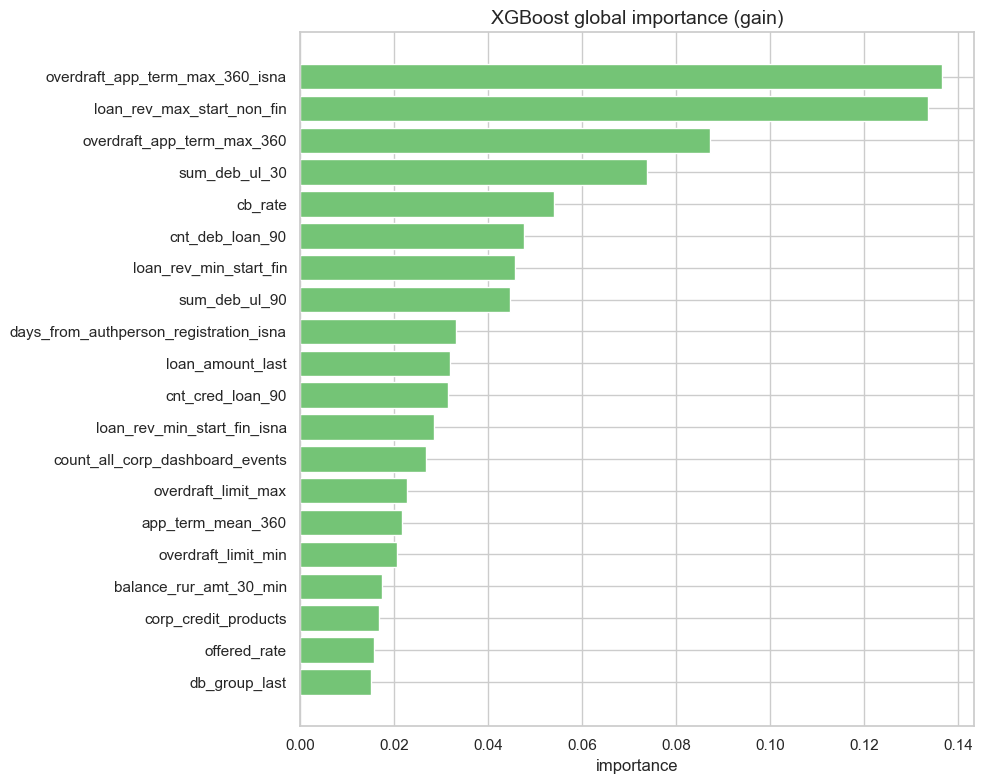

,feature,gain,rank
0,overdraft_app_term_max_360_isna,0.136576,1
1,loan_rev_max_start_non_fin,0.133594,2
2,overdraft_app_term_max_360,0.087273,3
3,sum_deb_ul_30,0.073894,4
4,cb_rate,0.054100,5
5,cnt_deb_loan_90,0.047720,6
6,loan_rev_min_start_fin,0.045715,7
7,sum_deb_ul_90,0.044603,8
8,days_from_authperson_registration_isna,0.033232,9
9,loan_amount_last,0.031785,10


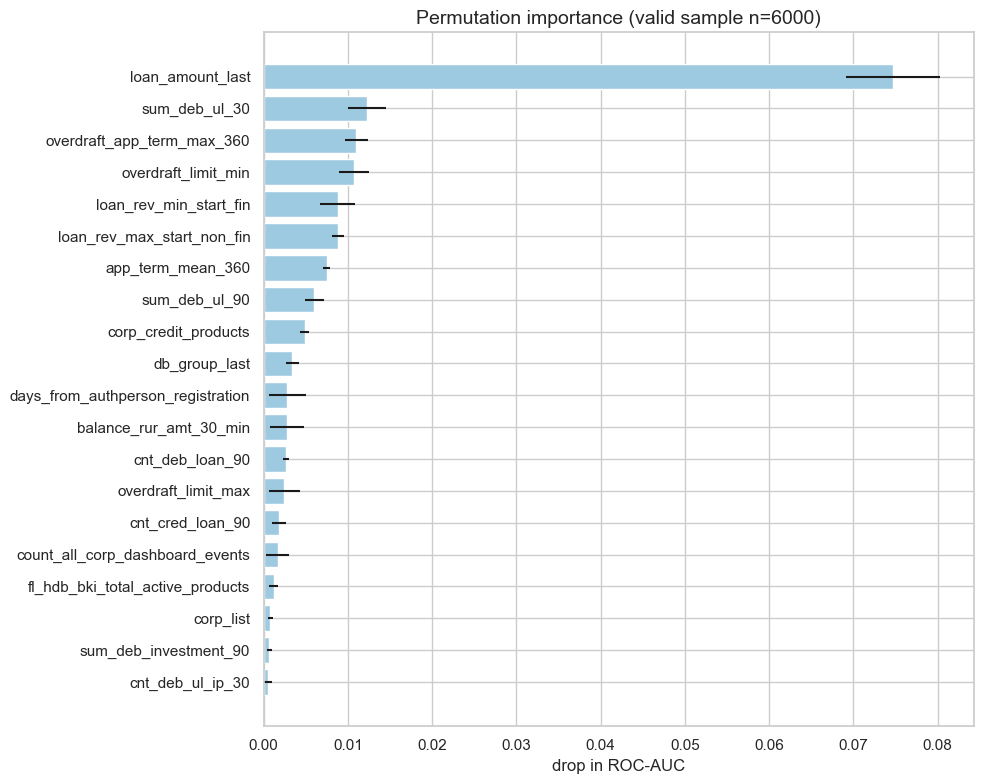

,feature,perm_mean,perm_std,rank
0,loan_amount_last,0.074690,0.005607,1
1,sum_deb_ul_30,0.012246,0.002268,2
2,overdraft_app_term_max_360,0.011020,0.001372,3
3,overdraft_limit_min,0.010764,0.001787,4
4,loan_rev_min_start_fin,0.008825,0.002084,5
5,loan_rev_max_start_non_fin,0.008798,0.000712,6
6,app_term_mean_360,0.007480,0.000454,7
7,sum_deb_ul_90,0.006012,0.001113,8
8,corp_credit_products,0.004861,0.000576,9
9,db_group_last,0.003420,0.000817,10


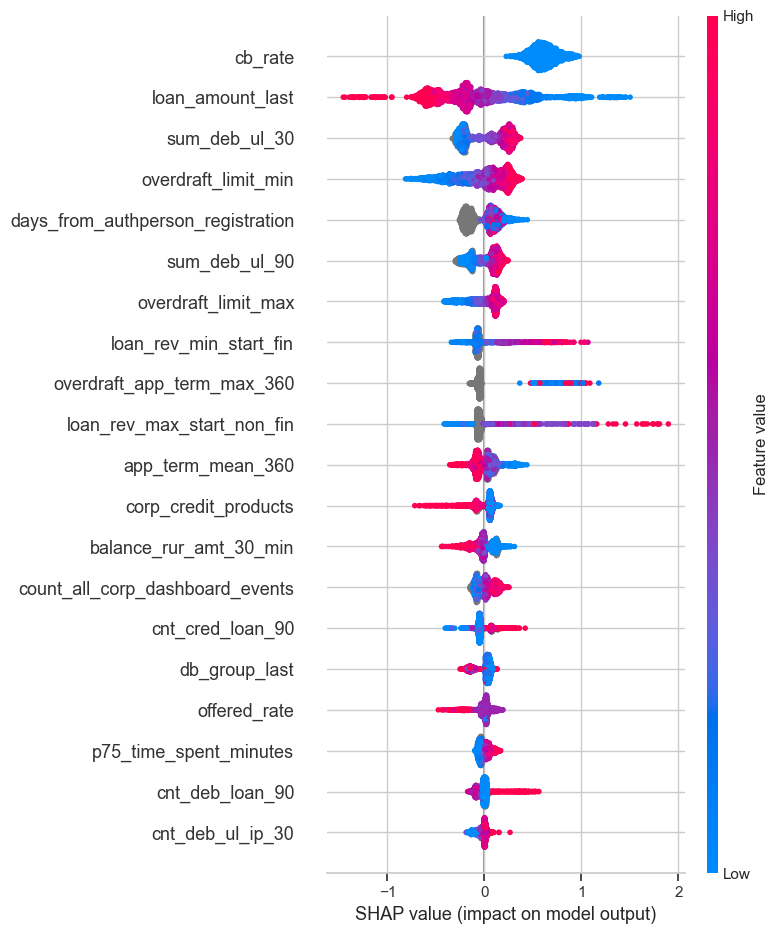

,feature,mean_abs_shap
0,cb_rate,0.611821
1,loan_amount_last,0.363383
2,sum_deb_ul_30,0.214846
3,overdraft_limit_min,0.201992
4,days_from_authperson_registration,0.137519
5,sum_deb_ul_90,0.125886
6,overdraft_limit_max,0.121832
7,loan_rev_min_start_fin,0.119803
8,overdraft_app_term_max_360,0.102511
9,loan_rev_max_start_non_fin,0.097128


,feature,gain,rank_gain,perm_mean,rank_perm,mean_abs_shap,avg_rank
29,sum_deb_ul_30,0.073894,4,0.012246,2,0.214846,3.0
22,overdraft_app_term_max_360,0.087273,3,0.011020,3,0.102511,3.0
17,loan_rev_max_start_non_fin,0.133594,2,0.008798,6,0.097128,4.0
16,loan_amount_last,0.031785,10,0.074690,1,0.363383,5.5
19,loan_rev_min_start_fin,0.045715,7,0.008825,5,0.119803,6.0
30,sum_deb_ul_90,0.044603,8,0.006012,8,0.125886,8.0
4,cnt_deb_loan_90,0.047720,6,0.002631,13,0.045827,9.5
25,overdraft_limit_min,0.020647,16,0.010764,4,0.201992,10.0
0,app_term_mean_360,0.021651,15,0.007480,7,0.091057,11.0
3,cnt_cred_loan_90,0.031549,11,0.001830,15,0.065868,13.0


In [15]:
%pip install -q xgboost shap

import shap
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_curve, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier

CUTOFF = "2025-02-01"
RANDOM_STATE = 42
CAT_COLS_RAW = ["db_group_last", "fl_adminarea"]
SHAP_SAMPLE = 4000
PERM_SAMPLE = 6000
PERM_REPEATS = 5

TOP5_ISNA_COLS = [
    "overdraft_app_term_max_360",
    "loan_rev_max_start_non_fin",
    "sum_deb_investment_90",
    "loan_rev_min_start_fin",
    "days_from_authperson_registration",
]


def encode_xgb_features(X_train, X_valid):
    X_tr = X_train.copy()
    X_va = X_valid.copy()
    num_cols = X_tr.select_dtypes(include="number").columns.tolist()
    X_tr[num_cols] = X_tr[num_cols].replace([np.inf, -np.inf], np.nan)
    X_va[num_cols] = X_va[num_cols].replace([np.inf, -np.inf], np.nan)
    for col in CAT_COLS_RAW:
        if col not in X_tr.columns:
            continue
        combined = pd.concat([X_tr[col], X_va[col]], axis=0).fillna("__MISSING__").astype(str)
        mapping = {v: i for i, v in enumerate(combined.unique())}
        X_tr[col] = X_tr[col].fillna("__MISSING__").astype(str).map(mapping).astype(int)
        X_va[col] = X_va[col].fillna("__MISSING__").astype(str).map(mapping).fillna(-1).astype(int)
    return X_tr, X_va


def build_raw_augmented(data):
    raw_features = [c for c in train_df.columns if c not in [TARGET_COL, ID_COL, DATE_COL]]
    X = data[raw_features].copy()
    X["is_sunday"] = (data[DATE_COL].dt.weekday == 6).astype(int)
    for col in TOP5_ISNA_COLS:
        X[f"{col}_isna"] = X[col].isna().astype(int)
    for col in CAT_COLS_RAW:
        if col in X.columns:
            X[col] = X[col].fillna("__MISSING__").astype(str)
    return X, raw_features


def fit_xgb_model(X_train, y_train, X_valid, y_valid):
    X_tr, X_va = encode_xgb_features(X_train, X_valid)
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=10,
        subsample=0.85,
        colsample_bytree=0.8,
        reg_alpha=0.2,
        reg_lambda=8.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        early_stopping_rounds=80,
    )
    model.fit(X_tr, y_train, eval_set=[(X_va, y_valid)], verbose=False)
    pred = model.predict_proba(X_va)[:, 1]
    return model, pred, X_tr, X_va


# --- train on valid split ---
data = train_df.copy()
data[DATE_COL] = pd.to_datetime(data[DATE_COL])

X, raw_features = build_raw_augmented(data)
y = data[TARGET_COL].astype(int)

train_mask = data[DATE_COL] < pd.Timestamp(CUTOFF)
valid_mask = ~train_mask

X_train = X.loc[train_mask]
X_valid = X.loc[valid_mask]
y_train = y.loc[train_mask]
y_valid = y.loc[valid_mask]

model, pred_valid, X_train_enc, X_valid_enc = fit_xgb_model(
    X_train, y_train, X_valid, y_valid
)

print(f"valid={len(X_valid):,} | features={X_valid.shape[1]} | ROC={roc_auc_score(y_valid, pred_valid):.6f}")

# --- 1) global XGB importance ---
global_imp = (
    pd.DataFrame({
        "feature": X_valid_enc.columns,
        "gain": model.feature_importances_,
    })
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)
global_imp["rank"] = np.arange(1, len(global_imp) + 1)

fig, ax = plt.subplots(figsize=(10, 8))
top_n = 20
plot_imp = global_imp.head(top_n).iloc[::-1]
ax.barh(plot_imp["feature"], plot_imp["gain"], color="#74c476")
ax.set_title("XGBoost global importance (gain)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

display(global_imp.head(20))

# --- 2) permutation importance (ROC-AUC drop) ---
rng = np.random.default_rng(RANDOM_STATE)
perm_idx = rng.choice(len(X_valid_enc), size=min(PERM_SAMPLE, len(X_valid_enc)), replace=False)
perm = permutation_importance(
    model,
    X_valid_enc.iloc[perm_idx],
    y_valid.iloc[perm_idx],
    n_repeats=PERM_REPEATS,
    random_state=RANDOM_STATE,
    scoring="roc_auc",
    n_jobs=-1,
)

perm_imp = (
    pd.DataFrame({
        "feature": X_valid_enc.columns,
        "perm_mean": perm.importances_mean,
        "perm_std": perm.importances_std,
    })
    .sort_values("perm_mean", ascending=False)
    .reset_index(drop=True)
)
perm_imp["rank"] = np.arange(1, len(perm_imp) + 1)

fig, ax = plt.subplots(figsize=(10, 8))
plot_perm = perm_imp.head(top_n).iloc[::-1]
ax.barh(plot_perm["feature"], plot_perm["perm_mean"], xerr=plot_perm["perm_std"], color="#9ecae1")
ax.set_title(f"Permutation importance (valid sample n={len(perm_idx)})")
ax.set_xlabel("drop in ROC-AUC")
plt.tight_layout()
plt.show()

display(perm_imp.head(20))

# --- 3) SHAP ---
shap_idx = rng.choice(len(X_valid_enc), size=min(SHAP_SAMPLE, len(X_valid_enc)), replace=False)
X_shap = X_valid_enc.iloc[shap_idx]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
plt.tight_layout()
plt.show()

shap_imp = (
    pd.DataFrame({
        "feature": X_shap.columns,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
display(shap_imp.head(20))

# merge all importances
importance_all = (
    global_imp[["feature", "gain", "rank"]]
    .rename(columns={"rank": "rank_gain"})
    .merge(perm_imp[["feature", "perm_mean", "rank"]].rename(columns={"rank": "rank_perm"}), on="feature", how="outer")
    .merge(shap_imp[["feature", "mean_abs_shap"]], on="feature", how="outer")
)
importance_all["avg_rank"] = importance_all[["rank_gain", "rank_perm"]].mean(axis=1)
importance_all = importance_all.sort_values("avg_rank")
display(importance_all.head(20))

Threshold=0.5000 | Youden threshold=0.1213
Confusion matrix [[TN, FP], [FN, TP]]:
[[16475   123]
 [ 1371   199]]


,group,n,target_rate,mean_score
0,FN,1371,1.0,0.178470
1,FP,123,0.0,0.624360
2,TN,16475,0.0,0.096841
3,TP,199,1.0,0.655612


Missing rate by group (%), sorted by |FP - TP|:


,feature,missing_pct_TP,missing_pct_FP,missing_pct_TN,missing_pct_FN,missing_pct_FP_minus_TP
0,sum_deb_investment_90,83.417085,67.479675,78.464340,74.325310,-15.937411
1,loan_rev_max_start_non_fin,19.597990,26.829268,90.658574,88.110868,7.231278
2,fl_hdb_bki_total_active_products,14.070352,8.130081,13.845220,13.056163,-5.940270
3,days_from_authperson_registration,17.085427,11.382114,44.503794,29.832239,-5.703313
4,loan_rev_min_start_fin,12.562814,15.447154,78.871017,69.219548,2.884340
5,count_all_corp_dashboard_events,3.517588,0.813008,24.594841,11.378556,-2.704580
6,p75_time_spent_minutes,3.517588,0.813008,24.594841,11.378556,-2.704580
7,corp_list,3.517588,0.813008,24.594841,11.378556,-2.704580
8,corp_credit_products,3.517588,0.813008,24.594841,11.378556,-2.704580
9,app_term_mean_360,11.055276,8.943089,34.986343,35.010941,-2.112187


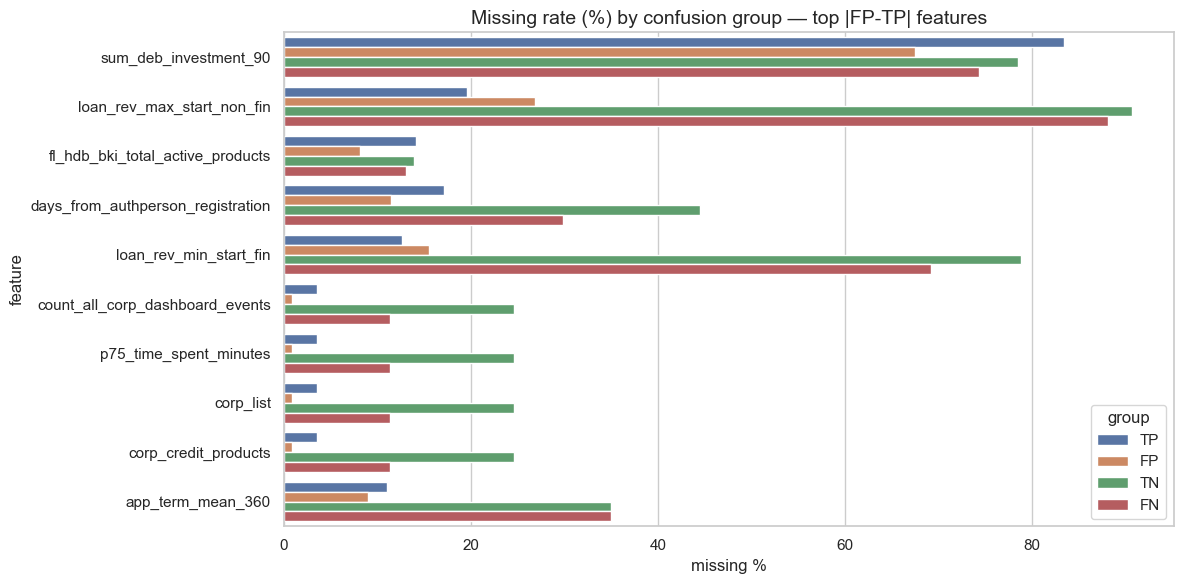

Numeric features: TP vs FP (among all valid rows)


,feature,mean_TP,mean_FP,mean_diff_TP_minus_FP,cohen_d_TP_vs_FP,missing_pct_TP,missing_pct_FP
0,sum_deb_investment_90,-0.121051,0.369364,-0.490415,-0.416289,83.417085,67.479675
1,balance_rur_amt_30_min,-4.550331,-3.503475,-1.046856,-0.339844,4.020101,4.878049
2,cnt_cred_loan_90,18.215661,15.912426,2.303235,0.291536,0.000000,0.000000
3,loan_rev_max_start_non_fin,0.582610,0.971170,-0.388560,-0.250357,19.597990,26.829268
4,cnt_deb_ul_ip_30,0.200554,0.136895,0.063659,0.236198,0.000000,0.000000
5,overdraft_app_term_max_360,0.571442,1.029907,-0.458465,-0.231483,21.105528,20.325203
6,cnt_deb_ul_ip_90,1.377707,1.020051,0.357655,0.227333,0.000000,0.000000
7,cnt_deb_loan_90,6.953818,6.285029,0.668789,0.211041,0.000000,0.000000
8,overdraft_limit_min,2.455208,2.038727,0.416480,0.182847,0.000000,0.000000
9,loan_amount_last,-0.015160,-0.210887,0.195727,0.148217,0.000000,0.000000


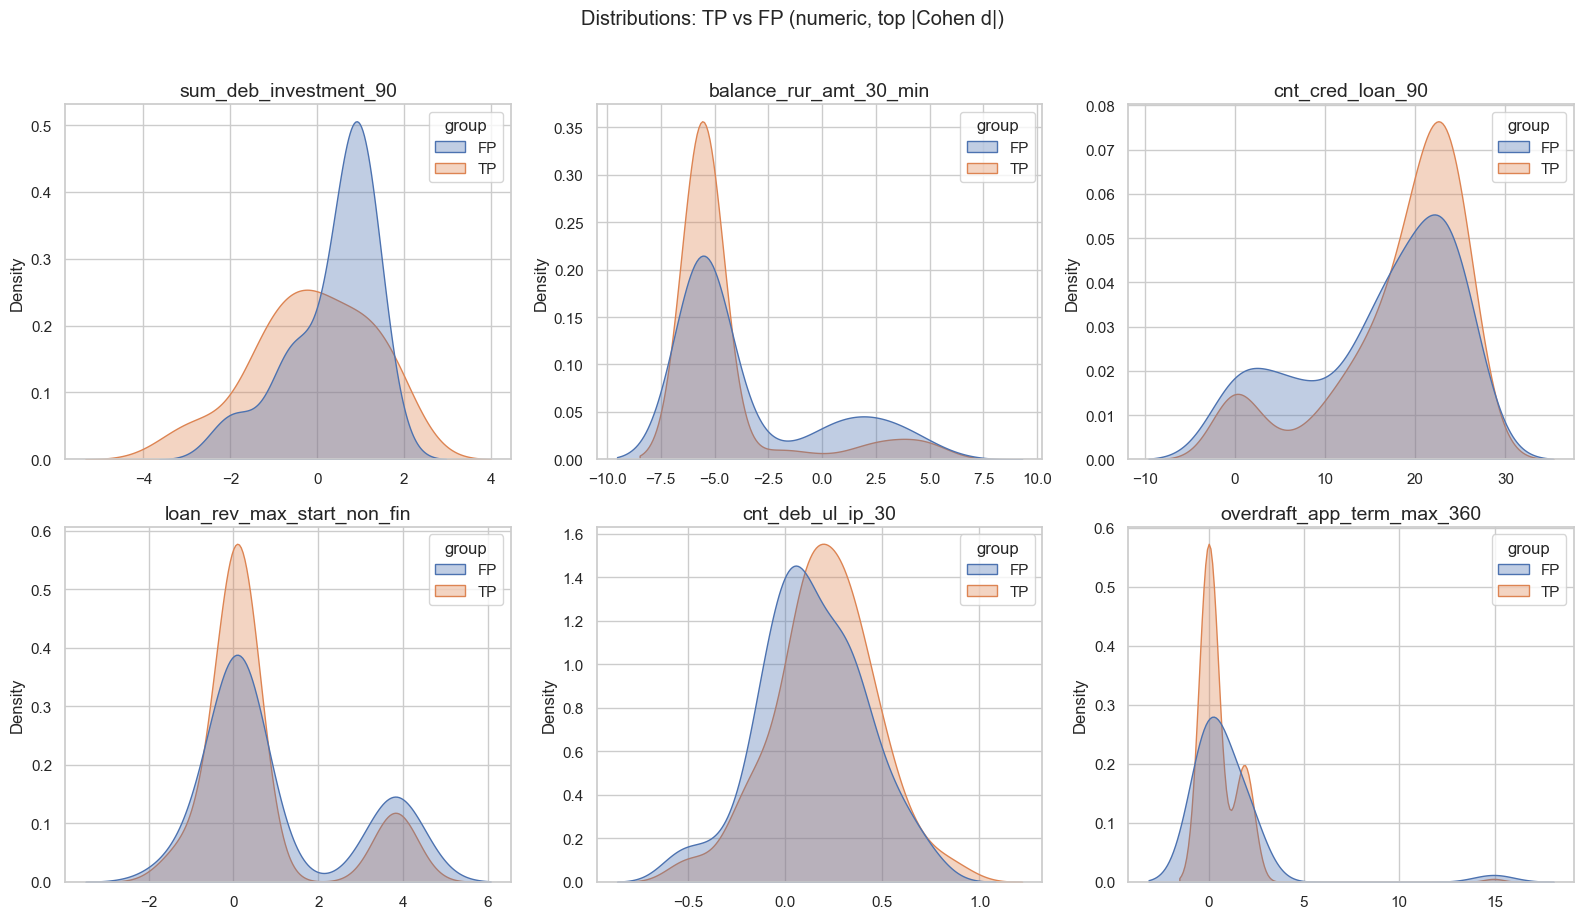


db_group_last: share within TP / FP rows


db_group_last,__MISSING__,bk,ebg,inn_scoring,lombard,overdraft,vkl,zalog_bk,zalog_light
group,,,,,,,,,
FP,0.089431,0.040650,0.008130,0.365854,0.000000,0.471545,0.008130,0.000000,0.016260
TP,0.110553,0.015075,0.035176,0.326633,0.005025,0.412060,0.045226,0.020101,0.030151



fl_adminarea: share within TP / FP rows


fl_adminarea,__MISSING__,Алтайский край,Архангельская область,Владимирская область,Волгоградская область,Вологодская область,Воронежская область,Иркутская область,Калининградская область,Кемеровская область - Кузбасс,...,Тюменская область,Удмуртская Республика,Ульяновская область,Хабаровский край,Ханты-Мансийский автономный окр.,Челябинская область,Чувашская Республика - Чувашия,Ярославская область,г. Москва,г. Санкт - Петербург
group,,,,,,,,,,,,,,,,,,,,,
FP,0.203252,0.00000,0.000000,0.00000,0.016260,0.016260,0.008130,0.008130,0.000000,0.008130,...,0.00813,0.00000,0.016260,0.000000,0.008130,0.056911,0.00000,0.000000,0.113821,0.081301
TP,0.211055,0.01005,0.005025,0.01005,0.015075,0.005025,0.020101,0.005025,0.005025,0.015075,...,0.00000,0.01005,0.005025,0.005025,0.005025,0.015075,0.01005,0.015075,0.100503,0.045226


Group profile (scores + missing + is_sunday):


,group,n,mean_score,median_score,missing_count_raw,missing_share_raw,is_sunday_rate
0,FN,1371,0.178470,0.150367,5.112327,0.204493,0.000729
1,FP,123,0.624360,0.620009,1.666667,0.066667,0.000000
2,TN,16475,0.096841,0.077453,6.675751,0.267030,0.003217
3,TP,199,0.655612,0.652261,1.969849,0.078794,0.000000


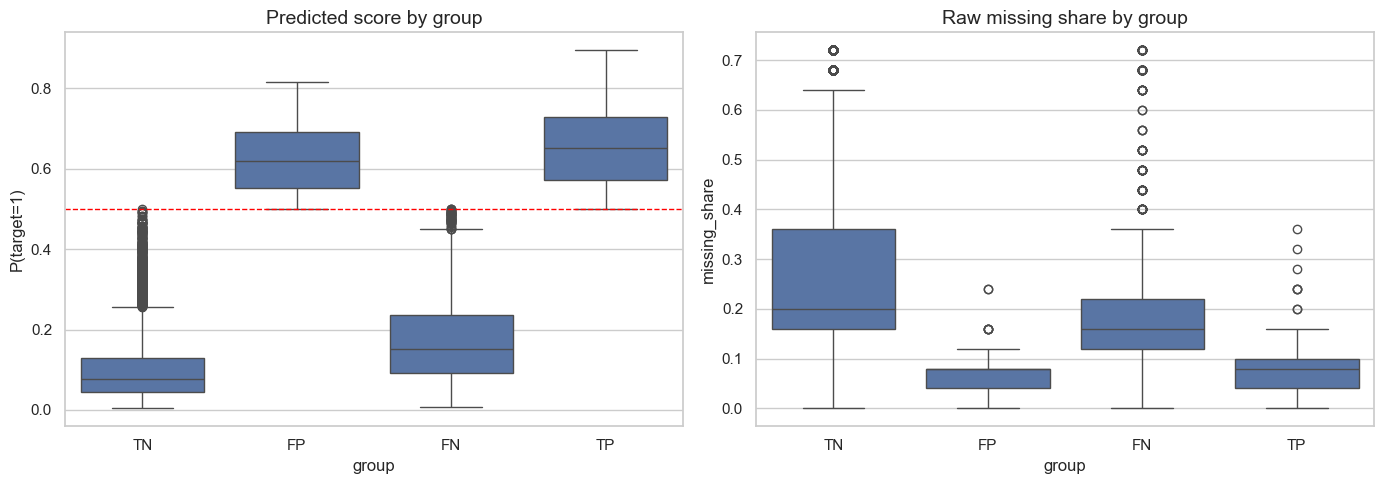

FP rows: 123 | TP rows: 199
Top signals separating TP from FP (|Cohen d|):


,feature,mean_TP,mean_FP,cohen_d_TP_vs_FP,missing_pct_TP,missing_pct_FP
0,sum_deb_investment_90,-0.121051,0.369364,-0.416289,83.417085,67.479675
1,balance_rur_amt_30_min,-4.550331,-3.503475,-0.339844,4.020101,4.878049
2,cnt_cred_loan_90,18.215661,15.912426,0.291536,0.000000,0.000000
3,loan_rev_max_start_non_fin,0.582610,0.971170,-0.250357,19.597990,26.829268
4,cnt_deb_ul_ip_30,0.200554,0.136895,0.236198,0.000000,0.000000
5,overdraft_app_term_max_360,0.571442,1.029907,-0.231483,21.105528,20.325203
6,cnt_deb_ul_ip_90,1.377707,1.020051,0.227333,0.000000,0.000000
7,cnt_deb_loan_90,6.953818,6.285029,0.211041,0.000000,0.000000
8,overdraft_limit_min,2.455208,2.038727,0.182847,0.000000,0.000000
9,loan_amount_last,-0.015160,-0.210887,0.148217,0.000000,0.000000


In [16]:
# --- 4) confusion groups on valid ---
fpr_curve, tpr_curve, thresholds = roc_curve(y_valid, pred_valid)
youden_idx = np.argmax(tpr_curve - fpr_curve)
thresh_youden = thresholds[youden_idx]

THRESHOLD = 0.5
analysis = X_valid.copy()
analysis["y_true"] = y_valid.values
analysis["y_pred"] = pred_valid
analysis["y_hat"] = (pred_valid >= THRESHOLD).astype(int)

def assign_group(row):
    if row["y_hat"] == 1 and row["y_true"] == 1:
        return "TP"
    if row["y_hat"] == 1 and row["y_true"] == 0:
        return "FP"
    if row["y_hat"] == 0 and row["y_true"] == 1:
        return "FN"
    return "TN"

analysis["group"] = analysis.apply(assign_group, axis=1)

group_stats = (
    analysis.groupby("group", observed=True)
    .agg(n=("y_true", "size"), target_rate=("y_true", "mean"), mean_score=("y_pred", "mean"))
    .reset_index()
)
cm = confusion_matrix(y_valid, analysis["y_hat"], labels=[0, 1])

print(f"Threshold={THRESHOLD:.4f} | Youden threshold={thresh_youden:.4f}")
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(cm)
display(group_stats)

# --- 5) missing profile by group (raw columns only) ---
missing_by_group = []
for col in raw_features:
    row = {"feature": col}
    for grp in ["TP", "FP", "TN", "FN"]:
        mask = analysis["group"] == grp
        row[f"missing_pct_{grp}"] = analysis.loc[mask, col].isna().mean() * 100
    row["missing_pct_FP_minus_TP"] = row["missing_pct_FP"] - row["missing_pct_TP"]
    missing_by_group.append(row)

missing_profile = (
    pd.DataFrame(missing_by_group)
    .sort_values("missing_pct_FP_minus_TP", key=np.abs, ascending=False)
    .reset_index(drop=True)
)

print("Missing rate by group (%), sorted by |FP - TP|:")
display(missing_profile.head(15))

fig, ax = plt.subplots(figsize=(12, 6))
miss_melt = missing_profile.melt(
    id_vars="feature",
    value_vars=["missing_pct_TP", "missing_pct_FP", "missing_pct_TN", "missing_pct_FN"],
    var_name="group",
    value_name="missing_pct",
)
miss_melt["group"] = miss_melt["group"].str.replace("missing_pct_", "")
top_miss_feats = missing_profile.head(10)["feature"].tolist()
sns.barplot(
    data=miss_melt[miss_melt["feature"].isin(top_miss_feats)],
    x="missing_pct",
    y="feature",
    hue="group",
    ax=ax,
)
ax.set_title("Missing rate (%) by confusion group — top |FP-TP| features")
ax.set_xlabel("missing %")
plt.tight_layout()
plt.show()

# --- 6) numeric distributions: FP vs TP ---
numeric_raw = [c for c in raw_features if pd.api.types.is_numeric_dtype(train_df[c])]

fp_tp_diff = []
for col in numeric_raw:
    tp_vals = analysis.loc[analysis["group"] == "TP", col]
    fp_vals = analysis.loc[analysis["group"] == "FP", col]
    tp_mean = tp_vals.mean()
    fp_mean = fp_vals.mean()
    pooled_std = analysis.loc[analysis["group"].isin(["TP", "FP"]), col].std()
    if pd.isna(pooled_std) or pooled_std == 0:
        cohen_d = np.nan
    else:
        cohen_d = (tp_mean - fp_mean) / pooled_std
    fp_tp_diff.append({
        "feature": col,
        "mean_TP": tp_mean,
        "mean_FP": fp_mean,
        "mean_diff_TP_minus_FP": tp_mean - fp_mean,
        "cohen_d_TP_vs_FP": cohen_d,
        "missing_pct_TP": tp_vals.isna().mean() * 100,
        "missing_pct_FP": fp_vals.isna().mean() * 100,
    })

fp_tp_table = (
    pd.DataFrame(fp_tp_diff)
    .sort_values("cohen_d_TP_vs_FP", key=np.abs, ascending=False)
    .reset_index(drop=True)
)

print("Numeric features: TP vs FP (among all valid rows)")
display(fp_tp_table.head(15))

top_plot_feats = fp_tp_table.head(6)["feature"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, col in zip(axes, top_plot_feats):
    plot_df = analysis.loc[analysis["group"].isin(["TP", "FP"]), ["group", col]].copy()
    sns.kdeplot(
        data=plot_df.dropna(),
        x=col,
        hue="group",
        common_norm=False,
        fill=True,
        alpha=0.35,
        ax=ax,
    )
    ax.set_title(col)
    ax.set_xlabel("")

for ax in axes[len(top_plot_feats):]:
    ax.axis("off")

plt.suptitle("Distributions: TP vs FP (numeric, top |Cohen d|)", y=1.02)
plt.tight_layout()
plt.show()

# --- 7) categorical: FP vs TP ---
for col in CAT_COLS_RAW:
    ct = pd.crosstab(
        analysis.loc[analysis["group"].isin(["TP", "FP"]), "group"],
        analysis.loc[analysis["group"].isin(["TP", "FP"]), col],
        normalize="index",
    )
    print(f"\n{col}: share within TP / FP rows")
    display(ct.head(10))

# --- 8) FP deep dive: score bins + missing_count ---
analysis["missing_count_raw"] = analysis[raw_features].isna().sum(axis=1)
analysis["missing_share_raw"] = analysis["missing_count_raw"] / len(raw_features)

fp_profile = (
    analysis.groupby("group", observed=True)
    .agg(
        n=("y_true", "size"),
        mean_score=("y_pred", "mean"),
        median_score=("y_pred", "median"),
        missing_count_raw=("missing_count_raw", "mean"),
        missing_share_raw=("missing_share_raw", "mean"),
        is_sunday_rate=("is_sunday", "mean"),
    )
    .reset_index()
)
print("Group profile (scores + missing + is_sunday):")
display(fp_profile)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=analysis, x="group", y="y_pred", order=["TN", "FP", "FN", "TP"], ax=axes[0])
axes[0].axhline(THRESHOLD, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Predicted score by group")
axes[0].set_ylabel("P(target=1)")

sns.boxplot(
    data=analysis,
    x="group",
    y="missing_share_raw",
    order=["TN", "FP", "FN", "TP"],
    ax=axes[1],
)
axes[1].set_title("Raw missing share by group")
axes[1].set_ylabel("missing_share")

plt.tight_layout()
plt.show()

# --- 9) all FP: top features where FP looks unlike TP ---
fp_only = analysis.loc[analysis["group"] == "FP"].copy()
tp_only = analysis.loc[analysis["group"] == "TP"].copy()

print(f"FP rows: {len(fp_only):,} | TP rows: {len(tp_only):,}")
print("Top signals separating TP from FP (|Cohen d|):")
display(fp_tp_table.head(10)[["feature", "mean_TP", "mean_FP", "cohen_d_TP_vs_FP", "missing_pct_TP", "missing_pct_FP"]])

----
**XGBoost: `missing_share` + `_isna` для всех sparse-колонок**
----

Сравнение с `raw + is_sunday + top5_isna`: ROC/PR и **FP-rate** на valid (threshold=0.5).

In [17]:
%pip install -q xgboost

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
)
from xgboost import XGBClassifier

CUTOFF = "2025-02-01"
RANDOM_STATE = 42
CAT_COLS_RAW = ["db_group_last", "fl_adminarea"]
THRESHOLD = 0.5
SPARSE_THRESHOLD = 50.0

TOP5_ISNA_COLS = [
    "overdraft_app_term_max_360",
    "loan_rev_max_start_non_fin",
    "sum_deb_investment_90",
    "loan_rev_min_start_fin",
    "days_from_authperson_registration",
]


def encode_xgb_features(X_train, X_valid):
    X_tr = X_train.copy()
    X_va = X_valid.copy()
    num_cols = X_tr.select_dtypes(include="number").columns.tolist()
    X_tr[num_cols] = X_tr[num_cols].replace([np.inf, -np.inf], np.nan)
    X_va[num_cols] = X_va[num_cols].replace([np.inf, -np.inf], np.nan)
    for col in CAT_COLS_RAW:
        if col not in X_tr.columns:
            continue
        combined = pd.concat([X_tr[col], X_va[col]], axis=0).fillna("__MISSING__").astype(str)
        mapping = {v: i for i, v in enumerate(combined.unique())}
        X_tr[col] = X_tr[col].fillna("__MISSING__").astype(str).map(mapping).astype(int)
        X_va[col] = X_va[col].fillna("__MISSING__").astype(str).map(mapping).fillna(-1).astype(int)
    return X_tr, X_va


def fit_xgb_raw(X_train, y_train, X_valid, y_valid):
    X_tr, X_va = encode_xgb_features(X_train, X_valid)
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=10,
        subsample=0.85,
        colsample_bytree=0.8,
        reg_alpha=0.2,
        reg_lambda=8.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        early_stopping_rounds=80,
    )
    model.fit(X_tr, y_train, eval_set=[(X_va, y_valid)], verbose=False)
    return model.predict_proba(X_va)[:, 1], model


def confusion_metrics(y_true, pred, threshold=THRESHOLD):
    y_hat = (pred >= threshold).astype(int)
    tp = int(((y_hat == 1) & (y_true == 1)).sum())
    fp = int(((y_hat == 1) & (y_true == 0)).sum())
    tn = int(((y_hat == 0) & (y_true == 0)).sum())
    fn = int(((y_hat == 0) & (y_true == 1)).sum())
    n = len(y_true)
    return {
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "fp_rate": fp / n,
        "fn_rate": fn / n,
        "pred_pos_rate": (tp + fp) / n,
        "precision": precision_score(y_true, y_hat, zero_division=0),
        "recall": recall_score(y_true, y_hat, zero_division=0),
        "f1": f1_score(y_true, y_hat, zero_division=0),
    }


def build_top5_variant(data, raw_features):
    X = data[raw_features].copy()
    X["is_sunday"] = (data[DATE_COL].dt.weekday == 6).astype(int)
    for col in TOP5_ISNA_COLS:
        X[f"{col}_isna"] = X[col].isna().astype(int)
    for col in CAT_COLS_RAW:
        if col in X.columns:
            X[col] = X[col].fillna("__MISSING__").astype(str)
    return X


def build_sparse_variant(data, raw_features, sparse_cols):
    X = data[raw_features].copy()
    X["is_sunday"] = (data[DATE_COL].dt.weekday == 6).astype(int)
    X["missing_count"] = X[raw_features].isna().sum(axis=1)
    X["missing_share"] = X["missing_count"] / len(raw_features)
    for col in sparse_cols:
        X[f"{col}_isna"] = X[col].isna().astype(int)
    for col in CAT_COLS_RAW:
        if col in X.columns:
            X[col] = X[col].fillna("__MISSING__").astype(str)
    return X


# --- data ---
data = train_df.copy()
data[DATE_COL] = pd.to_datetime(data[DATE_COL])

raw_features = [c for c in train_df.columns if c not in [TARGET_COL, ID_COL, DATE_COL]]
sparse_cols = [
    c for c in raw_features
    if train_df[c].isna().mean() * 100 > SPARSE_THRESHOLD
]

print(f"Sparse columns (>{SPARSE_THRESHOLD:.0f}% missing): {len(sparse_cols)}")
for col in sparse_cols:
    pct = train_df[col].isna().mean() * 100
    print(f"  {col}: {pct:.1f}%")

y = data[TARGET_COL].astype(int)
train_mask = data[DATE_COL] < pd.Timestamp(CUTOFF)
valid_mask = ~train_mask
y_valid = y.loc[valid_mask]

variants = {
    "raw + is_sunday + top5_isna": build_top5_variant(data, raw_features),
    "raw + is_sunday + missing_share + sparse_isna": build_sparse_variant(data, raw_features, sparse_cols),
}

rows = []
preds = {}

for name, X in variants.items():
    pred, model = fit_xgb_raw(
        X.loc[train_mask], y.loc[train_mask],
        X.loc[valid_mask], y_valid,
    )
    preds[name] = pred
    cm = confusion_metrics(y_valid, pred)
    rows.append({
        "variant": name,
        "n_features": X.shape[1],
        "roc_auc": roc_auc_score(y_valid, pred),
        "pr_auc": average_precision_score(y_valid, pred),
        **cm,
    })

results = pd.DataFrame(rows)
results["fp_rate_pct"] = results["fp_rate"] * 100
results["delta_fp_rate_vs_top5"] = results["fp_rate"] - results.loc[0, "fp_rate"]
results["delta_roc_vs_top5"] = results["roc_auc"] - results.loc[0, "roc_auc"]

display(
    results[[
        "variant", "n_features", "roc_auc", "pr_auc",
        "TP", "FP", "TN", "FN",
        "fp_rate_pct", "precision", "recall", "f1",
        "delta_roc_vs_top5", "delta_fp_rate_vs_top5",
    ]].style.format({
        "roc_auc": "{:.6f}",
        "pr_auc": "{:.6f}",
        "fp_rate_pct": "{:.2f}",
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1": "{:.4f}",
        "delta_roc_vs_top5": "{:+.6f}",
        "delta_fp_rate_vs_top5": "{:+.4f}",
    })
)

sparse_name = "raw + is_sunday + missing_share + sparse_isna"
analysis_sparse = variants[sparse_name].loc[valid_mask].copy()
analysis_sparse["y_true"] = y_valid.values
analysis_sparse["y_pred"] = preds[sparse_name]
analysis_sparse["y_hat"] = (preds[sparse_name] >= THRESHOLD).astype(int)

def assign_group(row):
    if row["y_hat"] == 1 and row["y_true"] == 1:
        return "TP"
    if row["y_hat"] == 1 and row["y_true"] == 0:
        return "FP"
    if row["y_hat"] == 0 and row["y_true"] == 1:
        return "FN"
    return "TN"

analysis_sparse["group"] = analysis_sparse.apply(assign_group, axis=1)

fp_tp_missing = (
    analysis_sparse.groupby("group", observed=True)[["missing_share", "missing_count"]]
    .mean()
    .reindex(["TP", "FP", "TN", "FN"])
)

print("Mean missing_share / missing_count by group (sparse variant):")
display(fp_tp_missing)

isna_cols = [f"{c}_isna" for c in sparse_cols]
fp_tp_isna = (
    analysis_sparse.groupby("group", observed=True)[isna_cols]
    .mean()
    .T
)
fp_tp_isna["FP_minus_TP"] = fp_tp_isna["FP"] - fp_tp_isna["TP"]
fp_tp_isna = fp_tp_isna.sort_values("FP_minus_TP", key=np.abs, ascending=False)

print("Mean _isna rate by group (sparse variant), top |FP-TP|:")
display(fp_tp_isna.head(10))

Note: you may need to restart the kernel to use updated packages.
Sparse columns (>50% missing): 5
  loan_rev_max_start_non_fin: 91.3%
  loan_rev_min_start_fin: 85.9%
  overdraft_app_term_max_360: 96.2%
  days_from_authperson_registration: 54.0%
  sum_deb_investment_90: 88.6%


,variant,n_features,roc_auc,pr_auc,TP,FP,TN,FN,fp_rate_pct,precision,recall,f1,delta_roc_vs_top5,delta_fp_rate_vs_top5
0,raw + is_sunday + top5_isna,31,0.763943,0.321301,199,123,16475,1371,0.68,0.6180,0.1268,0.2104,+0.000000,+0.0000
1,raw + is_sunday + missing_share + sparse_isna,33,0.765700,0.325863,222,132,16466,1348,0.73,0.6271,0.1414,0.2308,+0.001757,+0.0005


Mean missing_share / missing_count by group (sparse variant):


,missing_share,missing_count
group,,
TP,0.095495,2.387387
FP,0.085152,2.128788
TN,0.290800,7.270011
FN,0.229347,5.733680


Mean _isna rate by group (sparse variant), top |FP-TP|:


group,FN,FP,TN,TP,FP_minus_TP
sum_deb_investment_90_isna,0.744065,0.674242,0.784708,0.819820,-0.145577
loan_rev_max_start_non_fin_isna,0.884273,0.348485,0.906292,0.247748,0.100737
days_from_authperson_registration_isna,0.299703,0.121212,0.445160,0.175676,-0.054464
overdraft_app_term_max_360_isna,0.868694,0.234848,0.953541,0.216216,0.018632
loan_rev_min_start_fin_isna,0.701039,0.143939,0.789141,0.130631,0.013309


----
**Порог классификации: sweep на valid**
----

Модель `raw + is_sunday + missing_share + sparse_isna`. Метрики при разных threshold.

Note: you may need to restart the kernel to use updated packages.
valid base rate: 0.0864 | ROC=0.765700 | PR-AUC=0.325863


,goal,threshold,precision,recall,f1,TP,FP,FN,fp_rate,pred_pos_rate
0,default (0.5),0.500,0.6271,0.1414,0.2308,222.000000,132.000000,1348.000000,0.0073,0.0195
1,max F1,0.220,0.2965,0.4000,0.3406,628.000000,1490.000000,942.000000,0.0820,0.1166
2,"max precision, recall>=0.15",0.480,0.6189,0.1541,0.2468,242.000000,149.000000,1328.000000,0.0082,0.0215
3,"max precision, recall>=0.10",0.590,0.6709,0.1013,0.1760,159.000000,78.000000,1411.000000,0.0043,0.0130
4,min FP при TP>=50,0.730,0.7500,0.0382,0.0727,60.000000,20.000000,1510.000000,0.0011,0.0044
5,pred_pos_rate ~= base_rate (t=0.254),0.254,0.3369,0.3369,0.3369,529.000000,1041.000000,1041.000000,0.0573,0.0864


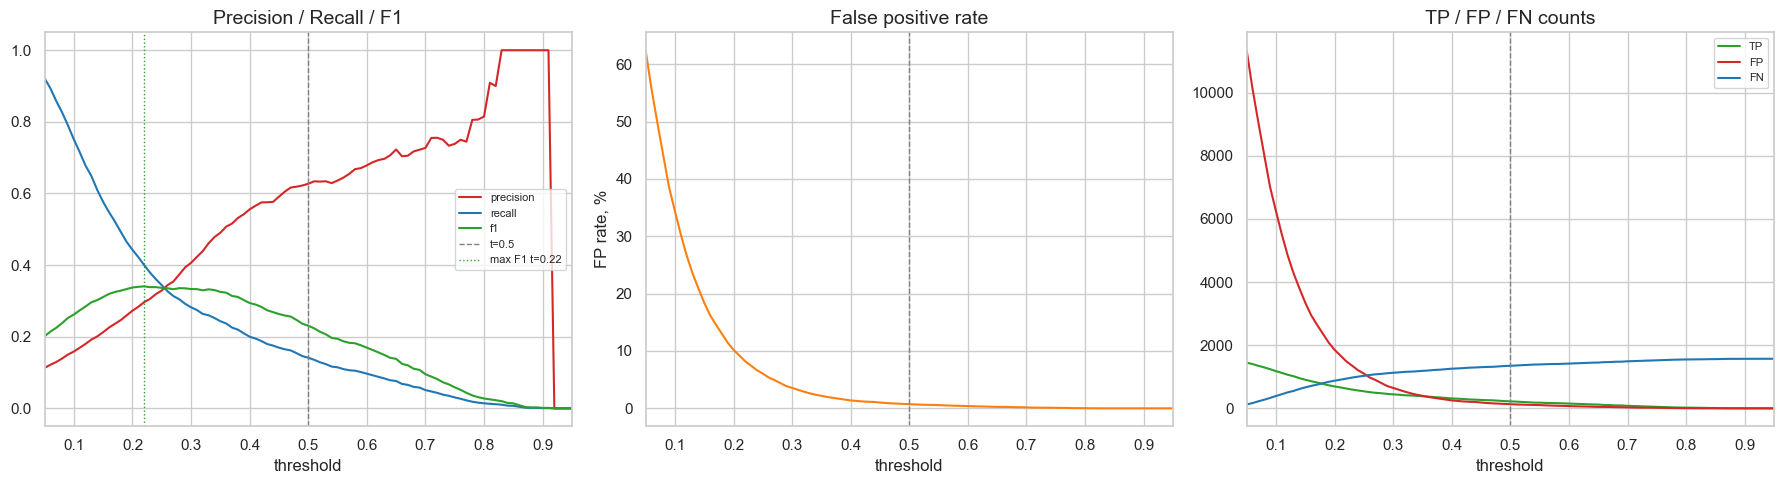

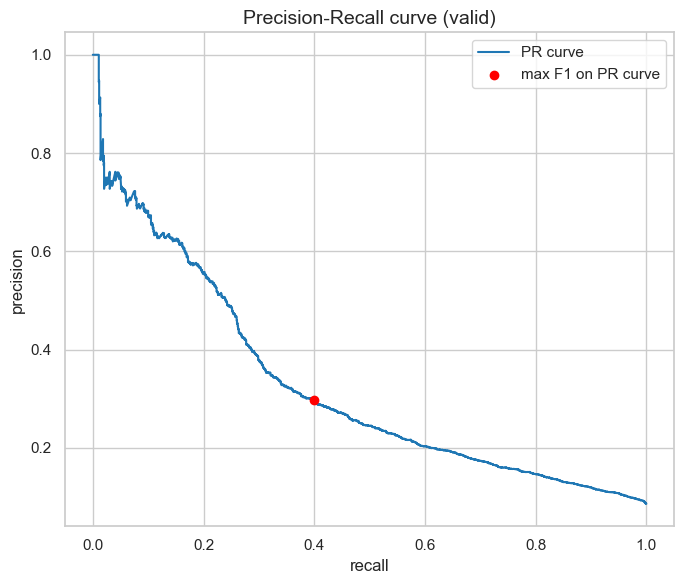

PR-curve max F1: t≈0.221 | precision=0.2977 | recall=0.3994 | f1=0.3411


,threshold,precision,recall,f1,TP,FP,FN,fp_rate
0,0.45,0.5911,0.1694,0.2634,266,184,1304,0.0101
1,0.48,0.6189,0.1541,0.2468,242,149,1328,0.0082
2,0.50,0.6271,0.1414,0.2308,222,132,1348,0.0073
3,0.55,0.6360,0.1146,0.1943,180,103,1390,0.0057
4,0.59,0.6709,0.1013,0.1760,159,78,1411,0.0043
5,0.60,0.6786,0.0968,0.1695,152,72,1418,0.0040
6,0.65,0.7229,0.0764,0.1382,120,46,1450,0.0025
7,0.70,0.7273,0.0510,0.0952,80,30,1490,0.0017


In [18]:
%pip install -q xgboost

from sklearn.metrics import precision_recall_curve, roc_auc_score, average_precision_score
from xgboost import XGBClassifier

CUTOFF = "2025-02-01"
RANDOM_STATE = 42
CAT_COLS_RAW = ["db_group_last", "fl_adminarea"]
SPARSE_THRESHOLD = 50.0


def encode_xgb_features(X_train, X_valid):
    X_tr = X_train.copy()
    X_va = X_valid.copy()
    num_cols = X_tr.select_dtypes(include="number").columns.tolist()
    X_tr[num_cols] = X_tr[num_cols].replace([np.inf, -np.inf], np.nan)
    X_va[num_cols] = X_va[num_cols].replace([np.inf, -np.inf], np.nan)
    for col in CAT_COLS_RAW:
        if col not in X_tr.columns:
            continue
        combined = pd.concat([X_tr[col], X_va[col]], axis=0).fillna("__MISSING__").astype(str)
        mapping = {v: i for i, v in enumerate(combined.unique())}
        X_tr[col] = X_tr[col].fillna("__MISSING__").astype(str).map(mapping).astype(int)
        X_va[col] = X_va[col].fillna("__MISSING__").astype(str).map(mapping).fillna(-1).astype(int)
    return X_tr, X_va


def fit_xgb_raw(X_train, y_train, X_valid, y_valid):
    X_tr, X_va = encode_xgb_features(X_train, X_valid)
    model = XGBClassifier(
        objective="binary:logistic", eval_metric="auc", tree_method="hist",
        n_estimators=2000, learning_rate=0.03, max_depth=4, min_child_weight=10,
        subsample=0.85, colsample_bytree=0.8, reg_alpha=0.2, reg_lambda=8.0,
        random_state=RANDOM_STATE, n_jobs=-1, early_stopping_rounds=80,
    )
    model.fit(X_tr, y_train, eval_set=[(X_va, y_valid)], verbose=False)
    return model.predict_proba(X_va)[:, 1]


def metrics_at_threshold(y_true, pred, threshold):
    y_hat = (pred >= threshold).astype(int)
    tp = int(((y_hat == 1) & (y_true == 1)).sum())
    fp = int(((y_hat == 1) & (y_true == 0)).sum())
    fn = int(((y_hat == 0) & (y_true == 1)).sum())
    tn = int(((y_hat == 0) & (y_true == 0)).sum())
    n = len(y_true)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {
        "threshold": threshold,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fp_rate": fp / n,
        "fn_rate": fn / n,
        "pred_pos_rate": (tp + fp) / n,
    }


def build_sparse_variant(data, raw_features, sparse_cols):
    X = data[raw_features].copy()
    X["is_sunday"] = (data[DATE_COL].dt.weekday == 6).astype(int)
    X["missing_count"] = X[raw_features].isna().sum(axis=1)
    X["missing_share"] = X["missing_count"] / len(raw_features)
    for col in sparse_cols:
        X[f"{col}_isna"] = X[col].isna().astype(int)
    for col in CAT_COLS_RAW:
        if col in X.columns:
            X[col] = X[col].fillna("__MISSING__").astype(str)
    return X


# --- train / predict ---
data = train_df.copy()
data[DATE_COL] = pd.to_datetime(data[DATE_COL])

raw_features = [c for c in train_df.columns if c not in [TARGET_COL, ID_COL, DATE_COL]]
sparse_cols = [c for c in raw_features if train_df[c].isna().mean() * 100 > SPARSE_THRESHOLD]

X = build_sparse_variant(data, raw_features, sparse_cols)
y = data[TARGET_COL].astype(int)

train_mask = data[DATE_COL] < pd.Timestamp(CUTOFF)
valid_mask = ~train_mask

y_valid = y.loc[valid_mask].values
pred_valid = fit_xgb_raw(X.loc[train_mask], y.loc[train_mask], X.loc[valid_mask], y.loc[valid_mask])

base_rate = y_valid.mean()
print(f"valid base rate: {base_rate:.4f} | ROC={roc_auc_score(y_valid, pred_valid):.6f} | PR-AUC={average_precision_score(y_valid, pred_valid):.6f}")

# --- sweep ---
threshold_grid = np.round(np.arange(0.05, 0.961, 0.01), 2)
thresh_df = pd.DataFrame([metrics_at_threshold(y_valid, pred_valid, t) for t in threshold_grid])

best_f1_row = thresh_df.loc[thresh_df["f1"].idxmax()]
prec_rec10 = thresh_df.loc[thresh_df[thresh_df["recall"] >= 0.10]["precision"].idxmax()]
prec_rec15 = thresh_df.loc[thresh_df[thresh_df["recall"] >= 0.15]["precision"].idxmax()]
min_fp_row = thresh_df.loc[thresh_df[thresh_df["TP"] >= 50]["FP"].idxmin()]

threshold_base_rate = float(np.quantile(pred_valid, 1 - base_rate))
row_base_rate = metrics_at_threshold(y_valid, pred_valid, threshold_base_rate)

recommendations = pd.DataFrame([
    {"goal": "default (0.5)", **metrics_at_threshold(y_valid, pred_valid, 0.5)},
    {"goal": "max F1", **best_f1_row.to_dict()},
    {"goal": "max precision, recall>=0.15", **prec_rec15.to_dict()},
    {"goal": "max precision, recall>=0.10", **prec_rec10.to_dict()},
    {"goal": "min FP при TP>=50", **min_fp_row.to_dict()},
    {"goal": f"pred_pos_rate ~= base_rate (t={threshold_base_rate:.3f})", **row_base_rate},
])

display(
    recommendations[[
        "goal", "threshold", "precision", "recall", "f1",
        "TP", "FP", "FN", "fp_rate", "pred_pos_rate",
    ]].style.format({
        "threshold": "{:.3f}",
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1": "{:.4f}",
        "fp_rate": "{:.4f}",
        "pred_pos_rate": "{:.4f}",
    })
)

# --- plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(thresh_df["threshold"], thresh_df["precision"], label="precision", color="#d62728")
axes[0].plot(thresh_df["threshold"], thresh_df["recall"], label="recall", color="#1f77b4")
axes[0].plot(thresh_df["threshold"], thresh_df["f1"], label="f1", color="#2ca02c")
axes[0].axvline(0.5, color="gray", linestyle="--", linewidth=1, label="t=0.5")
axes[0].axvline(best_f1_row["threshold"], color="#2ca02c", linestyle=":", linewidth=1, label=f"max F1 t={best_f1_row['threshold']:.2f}")
axes[0].set_xlabel("threshold")
axes[0].set_title("Precision / Recall / F1")
axes[0].legend(fontsize=8)
axes[0].set_xlim(0.05, 0.95)

axes[1].plot(thresh_df["threshold"], thresh_df["fp_rate"] * 100, color="#ff7f0e")
axes[1].axvline(0.5, color="gray", linestyle="--", linewidth=1)
axes[1].set_xlabel("threshold")
axes[1].set_ylabel("FP rate, %")
axes[1].set_title("False positive rate")
axes[1].set_xlim(0.05, 0.95)

axes[2].plot(thresh_df["threshold"], thresh_df["TP"], label="TP", color="#2ca02c")
axes[2].plot(thresh_df["threshold"], thresh_df["FP"], label="FP", color="#d62728")
axes[2].plot(thresh_df["threshold"], thresh_df["FN"], label="FN", color="#1f77b4")
axes[2].axvline(0.5, color="gray", linestyle="--", linewidth=1)
axes[2].set_xlabel("threshold")
axes[2].set_title("TP / FP / FN counts")
axes[2].legend(fontsize=8)
axes[2].set_xlim(0.05, 0.95)

plt.tight_layout()
plt.show()

# PR curve + iso-F1 lines
prec_curve, rec_curve, pr_thresholds = precision_recall_curve(y_valid, pred_valid)
f1_curve = 2 * prec_curve * rec_curve / (prec_curve + rec_curve + 1e-12)
best_pr_idx = int(np.argmax(f1_curve))

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(rec_curve, prec_curve, color="#1f77b4", label="PR curve")
ax.scatter(rec_curve[best_pr_idx], prec_curve[best_pr_idx], color="red", zorder=5, label="max F1 on PR curve")
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title("Precision-Recall curve (valid)")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"PR-curve max F1: t≈{pr_thresholds[best_pr_idx]:.3f} | "
    f"precision={prec_curve[best_pr_idx]:.4f} | recall={rec_curve[best_pr_idx]:.4f} | f1={f1_curve[best_pr_idx]:.4f}"
)

# handy slice
show_thresholds = [0.45, 0.48, 0.50, 0.55, 0.59, 0.60, 0.65, 0.70]
slice_df = pd.DataFrame([metrics_at_threshold(y_valid, pred_valid, t) for t in show_thresholds])
display(
    slice_df[[
        "threshold", "precision", "recall", "f1", "TP", "FP", "FN", "fp_rate",
    ]].style.format({
        "threshold": "{:.2f}",
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1": "{:.4f}",
        "fp_rate": "{:.4f}",
    })
)

----
**Импутация пропусков: регрессия / нейросеть (без `target_value`)**
----

Берём строки, где целевой столбец **известен**, делим 80/20 и предсказываем значение по остальным raw-признакам.

Note: you may need to restart the kernel to use updated packages.
Столбцов с пропусками: 20
  overdraft_app_term_max_360: 96.2%
  loan_rev_max_start_non_fin: 91.3%
  sum_deb_investment_90: 88.6%
  loan_rev_min_start_fin: 85.9%
  days_from_authperson_registration: 54.0%
  sum_deb_ul_30: 42.3%
  db_group_last: 38.5%
  app_term_mean_360: 38.5%
  sum_deb_ul_90: 37.3%
  p75_time_spent_minutes: 35.2%
  count_all_corp_dashboard_events: 35.2%
  corp_credit_products: 35.2%
  corp_list: 35.2%
  fl_adminarea: 29.8%
  balance_rur_amt_30_min: 24.0%
  cnt_deb_ul_ip_30: 23.0%
  cnt_deb_loan_90: 21.7%
  cnt_cred_loan_90: 21.7%
  cnt_deb_ul_ip_90: 20.9%
  fl_hdb_bki_total_active_products: 16.8%

=== overdraft_app_term_max_360 | missing=96.2% | known=5,509 | num ===
  ridge  | R2=0.1948
  rf     | R2=0.4369
  xgb    | R2=0.5108
  mlp    | R2=0.3130

=== loan_rev_max_start_non_fin | missing=91.3% | known=12,606 | num ===
  ridge  | R2=0.2640
  rf     | R2=0.5515
  xgb    | R2=0.6083
  mlp    | R2=0.4706


,impute_col,missing_pct,kind,best_model,score,metric,imputable
0,fl_adminarea,29.819404,categorical,xgb,0.039353,balanced_accuracy,False
1,days_from_authperson_registration,54.029510,numeric,xgb,0.132536,r2,False
2,fl_hdb_bki_total_active_products,16.777632,numeric,xgb,0.138385,r2,False
3,balance_rur_amt_30_min,23.978078,numeric,xgb,0.241651,r2,False
4,loan_rev_min_start_fin,85.861430,numeric,xgb,0.251044,r2,False
5,db_group_last,38.476050,categorical,xgb,0.359265,balanced_accuracy,False
6,sum_deb_investment_90,88.609277,numeric,xgb,0.368397,r2,False
7,app_term_mean_360,38.476050,numeric,xgb,0.374023,r2,False
8,corp_credit_products,35.243492,numeric,xgb,0.400812,r2,False
9,corp_list,35.243492,numeric,xgb,0.414993,r2,False


model,mlp,rf,ridge,xgb
impute_col,,,,
app_term_mean_360,0.2443,0.3532,0.0667,0.3740
balance_rur_amt_30_min,0.1961,0.1976,0.1237,0.2417
cnt_cred_loan_90,0.6261,0.6358,0.5060,0.6558
cnt_deb_loan_90,0.6308,0.6392,0.5647,0.6713
cnt_deb_ul_ip_30,0.9512,0.9512,0.9358,0.9565
cnt_deb_ul_ip_90,0.9448,0.9531,0.8354,0.9597
corp_credit_products,0.3458,0.3669,0.2916,0.4008
corp_list,0.3792,0.3996,0.3629,0.4150
count_all_corp_dashboard_events,0.7372,0.7661,0.6441,0.7844


model,logreg,mlp,rf,xgb
impute_col,,,,
db_group_last,0.2270,0.2923,0.2196,0.3593
fl_adminarea,0.0123,0.0133,0.0123,0.0394


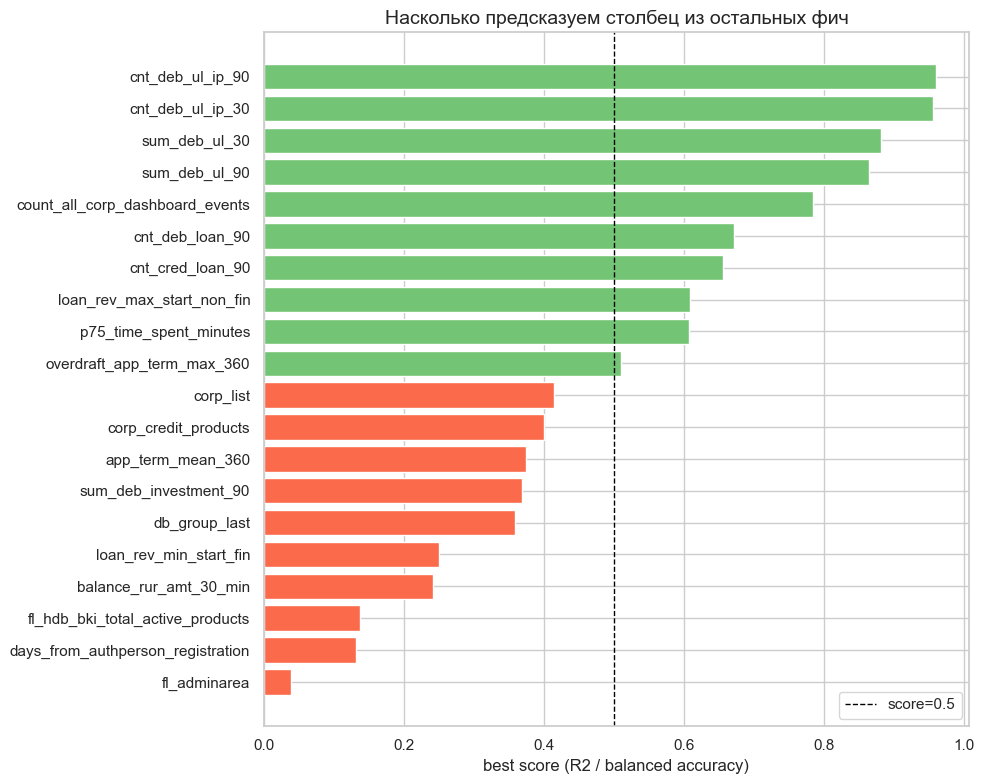

In [19]:
%pip install -q xgboost scikit-learn

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, balanced_accuracy_score,
)
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBRegressor, XGBClassifier

RANDOM_STATE = 42
MIN_KNOWN_ROWS = 500
CAT_COLS_RAW = ["db_group_last", "fl_adminarea"]


def prepare_impute_matrix(df, impute_col, raw_features):
    feat_cols = [c for c in raw_features if c != impute_col]
    X = df[feat_cols].copy()
    for col in CAT_COLS_RAW:
        if col in X.columns:
            X[col] = X[col].fillna("__MISSING__").astype("category").cat.codes
    return X


def get_regression_models():
    return {
        "ridge": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
            ("m", Ridge(alpha=1.0)),
        ]),
        "rf": RandomForestRegressor(
            n_estimators=200, max_depth=8, min_samples_leaf=20,
            random_state=RANDOM_STATE, n_jobs=-1,
        ),
        "xgb": XGBRegressor(
            objective="reg:squarederror", tree_method="hist",
            n_estimators=400, learning_rate=0.05, max_depth=5,
            min_child_weight=10, subsample=0.85, colsample_bytree=0.85,
            random_state=RANDOM_STATE, n_jobs=-1,
        ),
        "mlp": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
            ("m", MLPRegressor(
                hidden_layer_sizes=(128, 64), max_iter=300,
                early_stopping=True, random_state=RANDOM_STATE,
            )),
        ]),
    }


def get_classification_models(n_classes):
    xgb_params = dict(
        objective="binary:logistic" if n_classes == 2 else "multi:softprob",
        tree_method="hist",
        n_estimators=400, learning_rate=0.05, max_depth=5,
        min_child_weight=10, subsample=0.85, colsample_bytree=0.85,
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    if n_classes == 2:
        xgb_params["eval_metric"] = "logloss"
    else:
        xgb_params["eval_metric"] = "mlogloss"

    return {
        "logreg": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
            ("m", LogisticRegression(max_iter=500, random_state=RANDOM_STATE)),
        ]),
        "rf": RandomForestClassifier(
            n_estimators=200, max_depth=8, min_samples_leaf=20,
            random_state=RANDOM_STATE, n_jobs=-1,
        ),
        "xgb": XGBClassifier(**xgb_params),
        "mlp": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
            ("m", MLPClassifier(
                hidden_layer_sizes=(128, 64), max_iter=300,
                early_stopping=True, random_state=RANDOM_STATE,
            )),
        ]),
    }


raw_features = [c for c in train_df.columns if c not in [TARGET_COL, ID_COL, DATE_COL]]

impute_cols = (
    train_df[raw_features]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
impute_cols = impute_cols[impute_cols > 0].index.tolist()

print(f"Столбцов с пропусками: {len(impute_cols)}")
for col in impute_cols:
    print(f"  {col}: {train_df[col].isna().mean() * 100:.1f}%")

rows = []

for col in impute_cols:
    known_mask = train_df[col].notna()
    known_df = train_df.loc[known_mask]
    missing_pct = (1 - known_mask.mean()) * 100

    if len(known_df) < MIN_KNOWN_ROWS:
        print(f"skip {col}: known={len(known_df)}")
        continue

    X = prepare_impute_matrix(known_df, col, raw_features)
    is_categorical = col in CAT_COLS_RAW or known_df[col].dtype == object

    X_train, X_valid, y_train, y_valid = train_test_split(
        X, known_df[col].values, test_size=0.2, random_state=RANDOM_STATE,
    )

    print(f"\n=== {col} | missing={missing_pct:.1f}% | known={len(known_df):,} | {'cat' if is_categorical else 'num'} ===")

    if is_categorical:
        le = LabelEncoder()
        y_train_enc = le.fit_transform(y_train.astype(str))
        y_valid_enc = le.transform(y_valid.astype(str))

        for model_name, model in get_classification_models(len(le.classes_)).items():
            model.fit(X_train, y_train_enc)
            pred = model.predict(X_valid)
            rows.append({
                "impute_col": col,
                "kind": "categorical",
                "model": model_name,
                "missing_pct": missing_pct,
                "n_known": len(known_df),
                "r2": np.nan,
                "rmse": np.nan,
                "accuracy": accuracy_score(y_valid_enc, pred),
                "balanced_accuracy": balanced_accuracy_score(y_valid_enc, pred),
            })
            print(f"  {model_name:6s} | balanced_acc={balanced_accuracy_score(y_valid_enc, pred):.4f}")
    else:
        y_train_num = y_train.astype(float)
        y_valid_num = y_valid.astype(float)

        for model_name, model in get_regression_models().items():
            model.fit(X_train, y_train_num)
            pred = model.predict(X_valid)
            r2 = r2_score(y_valid_num, pred)
            rows.append({
                "impute_col": col,
                "kind": "numeric",
                "model": model_name,
                "missing_pct": missing_pct,
                "n_known": len(known_df),
                "r2": r2,
                "rmse": mean_squared_error(y_valid_num, pred) ** 0.5,
                "accuracy": np.nan,
                "balanced_accuracy": np.nan,
            })
            print(f"  {model_name:6s} | R2={r2:.4f}")

impute_results = pd.DataFrame(rows)

best_rows = []
for col in impute_cols:
    part = impute_results[impute_results["impute_col"] == col]
    if part.empty:
        continue
    if part.iloc[0]["kind"] == "numeric":
        best = part.loc[part["r2"].idxmax()]
        best_rows.append({
            "impute_col": col,
            "missing_pct": best["missing_pct"],
            "kind": "numeric",
            "best_model": best["model"],
            "score": best["r2"],
            "metric": "r2",
            "imputable": best["r2"] >= 0.5,
        })
    else:
        best = part.loc[part["balanced_accuracy"].idxmax()]
        best_rows.append({
            "impute_col": col,
            "missing_pct": best["missing_pct"],
            "kind": "categorical",
            "best_model": best["model"],
            "score": best["balanced_accuracy"],
            "metric": "balanced_accuracy",
            "imputable": best["balanced_accuracy"] >= 0.5,
        })

best_df = pd.DataFrame(best_rows).sort_values("score").reset_index(drop=True)

print("\n=== Best model per column ===")
display(best_df)

pivot_r2 = impute_results[impute_results["kind"] == "numeric"].pivot_table(
    index="impute_col", columns="model", values="r2", aggfunc="first",
)
display(pivot_r2.style.format("{:.4f}"))

cat_part = impute_results[impute_results["kind"] == "categorical"]
if len(cat_part) > 0:
    pivot_cat = cat_part.pivot_table(
        index="impute_col", columns="model", values="balanced_accuracy", aggfunc="first",
    )
    display(pivot_cat.style.format("{:.4f}"))

fig, ax = plt.subplots(figsize=(10, 8))
plot_df = best_df.sort_values("score")
colors = ["#74c476" if x else "#fb6a4a" for x in plot_df["imputable"]]
ax.barh(plot_df["impute_col"], plot_df["score"], color=colors)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="score=0.5")
ax.set_xlabel("best score (R2 / balanced accuracy)")
ax.set_title("Насколько предсказуем столбец из остальных фич")
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
%pip install -q xgboost scikit-learn

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, r2_score, balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor, XGBClassifier

CUTOFF = "2025-02-01"
RANDOM_STATE = 42
SCORE_THRESHOLD = 0.5
MIN_KNOWN_ROWS = 500
CAT_COLS_RAW = ["db_group_last", "fl_adminarea"]


def prepare_impute_matrix(df, impute_col, raw_features):
    feat_cols = [c for c in raw_features if c != impute_col]
    X = df[feat_cols].copy()
    for col in CAT_COLS_RAW:
        if col in X.columns:
            X[col] = X[col].fillna("__MISSING__").astype("category").cat.codes
    return X


def get_regression_model():
    return XGBRegressor(
        objective="reg:squarederror", tree_method="hist",
        n_estimators=400, learning_rate=0.05, max_depth=5,
        min_child_weight=10, subsample=0.85, colsample_bytree=0.85,
        random_state=RANDOM_STATE, n_jobs=-1,
    )


def get_classification_model(n_classes):
    if n_classes == 2:
        return XGBClassifier(
            objective="binary:logistic", eval_metric="logloss", tree_method="hist",
            n_estimators=400, learning_rate=0.05, max_depth=5,
            min_child_weight=10, subsample=0.85, colsample_bytree=0.85,
            random_state=RANDOM_STATE, n_jobs=-1,
        )
    return XGBClassifier(
        objective="multi:softprob", eval_metric="mlogloss", tree_method="hist",
        n_estimators=400, learning_rate=0.05, max_depth=5,
        min_child_weight=10, subsample=0.85, colsample_bytree=0.85,
        random_state=RANDOM_STATE, n_jobs=-1,
    )


def evaluate_imputability(col, train_known_df, raw_features):
    is_cat = col in CAT_COLS_RAW or train_known_df[col].dtype == object
    X = prepare_impute_matrix(train_known_df, col, raw_features)
    y = train_known_df[col].values

    X_train, X_valid, y_train, y_valid = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )

    if is_cat:
        le = LabelEncoder()
        y_train_enc = le.fit_transform(y_train.astype(str))
        y_valid_enc = le.transform(y_valid.astype(str))
        model = get_classification_model(len(le.classes_))
        model.fit(X_train, y_train_enc)
        pred = model.predict(X_valid)
        score = balanced_accuracy_score(y_valid_enc, pred)
        return {"impute_col": col, "kind": "categorical", "score": score, "imputable": score >= SCORE_THRESHOLD}

    model = get_regression_model()
    model.fit(X_train, y_train.astype(float))
    pred = model.predict(X_valid)
    score = r2_score(y_valid.astype(float), pred)
    return {"impute_col": col, "kind": "numeric", "score": score, "imputable": score >= SCORE_THRESHOLD}


def fit_final_imputer(col, train_known_df, raw_features, kind):
    X = prepare_impute_matrix(train_known_df, col, raw_features)
    y = train_known_df[col].values

    if kind == "categorical":
        le = LabelEncoder()
        y_enc = le.fit_transform(y.astype(str))
        model = get_classification_model(len(le.classes_))
        model.fit(X, y_enc)
        return model, le

    model = get_regression_model()
    model.fit(X, y.astype(float))
    return model, None


def apply_imputer(df, col, raw_features, model, label_encoder=None):
    out = df[col].copy()
    miss_mask = out.isna()
    if miss_mask.sum() == 0:
        return out

    X_miss = prepare_impute_matrix(df.loc[miss_mask], col, raw_features)
    pred = model.predict(X_miss)

    if label_encoder is not None:
        pred = label_encoder.inverse_transform(pred.astype(int))

    out.loc[miss_mask] = pred
    return out


def encode_xgb_features(X_train, X_valid):
    X_tr = X_train.copy()
    X_va = X_valid.copy()

    num_cols = X_tr.select_dtypes(include="number").columns.tolist()
    X_tr[num_cols] = X_tr[num_cols].replace([np.inf, -np.inf], np.nan)
    X_va[num_cols] = X_va[num_cols].replace([np.inf, -np.inf], np.nan)

    for col in CAT_COLS_RAW:
        if col not in X_tr.columns:
            continue
        combined = pd.concat([X_tr[col], X_va[col]], axis=0).fillna("__MISSING__").astype(str)
        mapping = {v: i for i, v in enumerate(combined.unique())}
        X_tr[col] = X_tr[col].fillna("__MISSING__").astype(str).map(mapping).astype(int)
        X_va[col] = X_va[col].fillna("__MISSING__").astype(str).map(mapping).fillna(-1).astype(int)

    return X_tr, X_va


def fit_xgb_and_score(X_train, y_train, X_valid, y_valid):
    X_tr, X_va = encode_xgb_features(X_train, X_valid)
    model = XGBClassifier(
        objective="binary:logistic", eval_metric="auc", tree_method="hist",
        n_estimators=2000, learning_rate=0.03, max_depth=4, min_child_weight=10,
        subsample=0.85, colsample_bytree=0.8, reg_alpha=0.2, reg_lambda=8.0,
        random_state=RANDOM_STATE, n_jobs=-1, early_stopping_rounds=80,
    )
    model.fit(X_tr, y_train, eval_set=[(X_va, y_valid)], verbose=False)
    pred = model.predict_proba(X_va)[:, 1]
    return {
        "roc_auc": roc_auc_score(y_valid, pred),
        "pr_auc": average_precision_score(y_valid, pred),
        "n_features": X_train.shape[1],
    }


# ========== 1. data split ==========
data = train_df.copy()
data[DATE_COL] = pd.to_datetime(data[DATE_COL])

raw_features = [c for c in data.columns if c not in [TARGET_COL, ID_COL, DATE_COL]]
missing_cols = [c for c in raw_features if data[c].isna().any()]

train_mask = data[DATE_COL] < pd.Timestamp(CUTOFF)
valid_mask = ~train_mask

train_df_part = data.loc[train_mask]
y_train = data.loc[train_mask, TARGET_COL].astype(int)
y_valid = data.loc[valid_mask, TARGET_COL].astype(int)

# ========== 2. select imputable cols (train only) ==========
impute_meta = []
for col in missing_cols:
    train_known = train_df_part[train_df_part[col].notna()]
    if len(train_known) < MIN_KNOWN_ROWS:
        continue
    impute_meta.append(evaluate_imputability(col, train_known, raw_features))

impute_meta_df = pd.DataFrame(impute_meta).sort_values("score", ascending=False)
imputable_cols = impute_meta_df.loc[impute_meta_df["imputable"], "impute_col"].tolist()
non_imputable_cols = [c for c in missing_cols if c not in imputable_cols]

print("Imputable columns:")
display(impute_meta_df)

# ========== 3. build imputed_df ==========
imputed_df = data[raw_features].copy()

for col in missing_cols:
    imputed_df[f"{col}_isna"] = data[col].isna().astype(int)

for row in impute_meta_df.itertuples():
    if not row.imputable:
        continue
    col = row.impute_col
    train_known = train_df_part[train_df_part[col].notna()]
    model, le = fit_final_imputer(col, train_known, raw_features, row.kind)
    imputed_df[col] = apply_imputer(data, col, raw_features, model, le)

print(f"imputed_df shape: {imputed_df.shape}")

# ========== 4. three datasets ==========
def build_dataset(mode):
    X = imputed_df[raw_features].copy()

    if mode == "all_isna":
        isna_cols = [f"{c}_isna" for c in missing_cols]
    elif mode == "isna_imputed":
        isna_cols = [f"{c}_isna" for c in imputable_cols]
    elif mode == "isna_not_imputed":
        isna_cols = [f"{c}_isna" for c in non_imputable_cols]
    else:
        raise ValueError(mode)

    for col in isna_cols:
        X[col] = imputed_df[col]

    for col in CAT_COLS_RAW:
        if col in X.columns:
            X[col] = X[col].fillna("__MISSING__").astype(str)

    return X


datasets = {
    "all_isna + imputed": build_dataset("all_isna"),
    "isna_imputed_only + imputed": build_dataset("isna_imputed"),
    "isna_not_imputed_only + imputed": build_dataset("isna_not_imputed"),
}

# ========== 5. train & compare ==========
results = []
for name, X in datasets.items():
    metrics = fit_xgb_and_score(
        X.loc[train_mask], y_train,
        X.loc[valid_mask], y_valid,
    )
    results.append({"variant": name, **metrics})

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
display(results_df)

print("Imputed:", imputable_cols)
print("Not imputed:", non_imputable_cols)

Note: you may need to restart the kernel to use updated packages.
Imputable columns:


,impute_col,kind,score,imputable
4,cnt_deb_ul_ip_90,numeric,0.958306,True
5,cnt_deb_ul_ip_30,numeric,0.953928,True
2,sum_deb_ul_30,numeric,0.874767,True
1,sum_deb_ul_90,numeric,0.861778,True
15,count_all_corp_dashboard_events,numeric,0.790280,True
3,cnt_deb_loan_90,numeric,0.675209,True
7,cnt_cred_loan_90,numeric,0.659849,True
8,loan_rev_max_start_non_fin,numeric,0.643164,True
16,p75_time_spent_minutes,numeric,0.602775,True
11,overdraft_app_term_max_360,numeric,0.513899,True


imputed_df shape: (145241, 45)


,variant,roc_auc,pr_auc,n_features
0,all_isna + imputed,0.763465,0.317282,45
1,isna_imputed_only + imputed,0.762862,0.316343,35
2,isna_not_imputed_only + imputed,0.761735,0.308971,35


Imputed: ['cnt_deb_ul_ip_90', 'cnt_deb_ul_ip_30', 'sum_deb_ul_30', 'sum_deb_ul_90', 'count_all_corp_dashboard_events', 'cnt_deb_loan_90', 'cnt_cred_loan_90', 'loan_rev_max_start_non_fin', 'p75_time_spent_minutes', 'overdraft_app_term_max_360']
Not imputed: ['corp_credit_products', 'balance_rur_amt_30_min', 'loan_rev_min_start_fin', 'app_term_mean_360', 'days_from_authperson_registration', 'fl_hdb_bki_total_active_products', 'corp_list', 'sum_deb_investment_90', 'db_group_last', 'fl_adminarea']


In [28]:
CUTOFF = "2025-02-01"
RANDOM_STATE = 42
CAT_COLS_RAW = ["db_group_last", "fl_adminarea"]

# numeric cols to segment: (col, n_bins)
SEGMENT_SPEC = {
    "overdraft_app_term_max_360": 2,
    "loan_rev_max_start_non_fin": 2,
    "loan_rev_min_start_fin": 2,
    "sum_deb_investment_90": 2,
    "days_from_authperson_registration": 3,
    "sum_deb_ul_30": 3,
    "sum_deb_ul_90": 3,
    "app_term_mean_360": 3,
    "p75_time_spent_minutes": 3,
    "count_all_corp_dashboard_events": 3,
    "corp_credit_products": 3,
    "corp_list": 3,
    "balance_rur_amt_30_min": 3,
    "cnt_deb_ul_ip_30": 3,
    "cnt_deb_ul_ip_90": 3,
    "cnt_deb_loan_90": 3,
    "cnt_cred_loan_90": 3,
    "fl_hdb_bki_total_active_products": 3,
}


def fit_segment_edges(train_series, n_bins):
    clean = train_series.replace([np.inf, -np.inf], np.nan).dropna()
    if len(clean) < 100:
        return None
    qs = np.linspace(0, 1, n_bins + 1)
    edges = np.unique(np.quantile(clean, qs))
    if len(edges) < 3:
        return None
    return edges


def apply_segment(series, edges):
    out = pd.Series(index=series.index, dtype="object")
    miss = series.isna()
    out.loc[miss] = "__MISSING__"

    known = series.loc[~miss].replace([np.inf, -np.inf], np.nan)
    known = known.dropna()
    if len(known) == 0:
        return out.fillna("__MISSING__")

    binned = pd.cut(known, bins=edges, include_lowest=True, duplicates="drop")
    labels = [f"seg_{i}" for i in range(binned.cat.categories.size)]
    binned = pd.cut(known, bins=edges, include_lowest=True, labels=labels, duplicates="drop")
    out.loc[binned.index] = binned.astype(str)
    return out.fillna("__MISSING__")


def add_sparse_segments(df, train_mask, segment_spec, mode="replace"):
  # mode: "replace" | "add" | "only_seg"
    out = df.copy()
    train_part = out.loc[train_mask]

    for col, n_bins in segment_spec.items():
        if col not in out.columns:
            continue
        edges = fit_segment_edges(train_part[col], n_bins)
        seg_col = f"{col}_seg"
        if edges is None:
            out[seg_col] = out[col].apply(lambda x: "__MISSING__" if pd.isna(x) else "seg_0")
        else:
            out[seg_col] = apply_segment(out[col], edges)

        out[f"{col}_isna"] = out[col].isna().astype(int)

        if mode == "replace":
            out = out.drop(columns=[col])
        elif mode == "only_seg":
            out = out.drop(columns=[col])

    return out


def encode_xgb_features(X_train, X_valid):
    X_tr = X_train.copy()
    X_va = X_valid.copy()
    num_cols = X_tr.select_dtypes(include="number").columns.tolist()
    X_tr[num_cols] = X_tr[num_cols].replace([np.inf, -np.inf], np.nan)
    X_va[num_cols] = X_va[num_cols].replace([np.inf, -np.inf], np.nan)

    seg_cols = [c for c in X_tr.columns if c.endswith("_seg")]
    cat_cols = list(set(CAT_COLS_RAW + seg_cols))

    for col in cat_cols:
        if col not in X_tr.columns:
            continue
        combined = pd.concat([X_tr[col], X_va[col]], axis=0).fillna("__MISSING__").astype(str)
        mapping = {v: i for i, v in enumerate(combined.unique())}
        X_tr[col] = X_tr[col].fillna("__MISSING__").astype(str).map(mapping).astype(int)
        X_va[col] = X_va[col].fillna("__MISSING__").astype(str).map(mapping).fillna(-1).astype(int)
    return X_tr, X_va


def fit_xgb_and_score(X_train, y_train, X_valid, y_valid):
    X_tr, X_va = encode_xgb_features(X_train, X_valid)
    model = XGBClassifier(
        objective="binary:logistic", eval_metric="auc", tree_method="hist",
        n_estimators=2000, learning_rate=0.03, max_depth=4, min_child_weight=10,
        subsample=0.85, colsample_bytree=0.8, reg_alpha=0.2, reg_lambda=8.0,
        random_state=RANDOM_STATE, n_jobs=-1, early_stopping_rounds=80,
    )
    model.fit(X_tr, y_train, eval_set=[(X_va, y_valid)], verbose=False)
    pred = model.predict_proba(X_va)[:, 1]
    return roc_auc_score(y_valid, pred), average_precision_score(y_valid, pred)


# --- run ---
data = train_df.copy()
data[DATE_COL] = pd.to_datetime(data[DATE_COL])
train_mask = data[DATE_COL] < pd.Timestamp(CUTOFF)
valid_mask = ~train_mask
y_train = data.loc[train_mask, TARGET_COL].astype(int)
y_valid = data.loc[valid_mask, TARGET_COL].astype(int)

raw_features = [c for c in data.columns if c not in [TARGET_COL, ID_COL, DATE_COL]]
base = data[raw_features].copy()

results = []
for mode, label in [
    ("none", "raw baseline"),
    ("replace", "sparse cols -> seg + isna"),
    ("add", "raw + seg + isna"),
]:
    if mode == "none":
        X = base.copy()
    else:
        X = add_sparse_segments(base, train_mask, SEGMENT_SPEC, mode=mode)

    for col in CAT_COLS_RAW:
        if col in X.columns:
            X[col] = X[col].fillna("__MISSING__").astype(str)

    roc, pr = fit_xgb_and_score(X.loc[train_mask], y_train, X.loc[valid_mask], y_valid)
    results.append({"variant": label, "roc_auc": roc, "pr_auc": pr, "n_features": X.shape[1]})

display(pd.DataFrame(results).sort_values("roc_auc", ascending=False))

,variant,roc_auc,pr_auc,n_features
0,raw baseline,0.765764,0.327038,25
2,raw + seg + isna,0.764140,0.325178,61
1,sparse cols -> seg + isna,0.747202,0.286218,43


In [30]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss

# ========== config ==========
CUTOFF = "2025-02-01"
N_FOLDS = 5
RANDOM_STATE = 42
CAT_COLS = ["db_group_last", "fl_adminarea"]
MODEL_NAMES = ["xgb_base", "cat_base", "lgbm_base"]

EXTRA_CALENDAR_DROP = [
    "decision_day_num", "decision_month", "decision_quarter",
    "decision_weekofyear", "decision_dayofweek", "decision_dayofmonth",
    "is_weekend", "is_month_start", "is_month_end",
]

HIGH_CORR_DROP_COLS = [
    "overdraft_limit_min", "cnt_deb_ul_ip_30", "sum_deb_ul_30", "decision_day_num",
]

REDUCED_V2_DROP = [
    "rate_ratio", "decision_day_num", "decision_weekofyear", "decision_dayofmonth",
    "decision_quarter", "is_month_start", "is_month_end",
    "loan_to_limit_min", "loan_to_limit_mean",
    "sum_deb_ul_ratio_30_90", "cnt_deb_ul_ip_ratio_30_90",
    "sum_deb_ul_per_cnt_30", "digital_activity_per_time", "credit_activity_ratio",
]

RATIO_ENGINEERED_COLS = [
    "rate_spread", "abs_rate_spread", "rate_ratio", "overdraft_range", "overdraft_mean",
    "loan_to_limit_min", "loan_to_limit_max", "loan_to_limit_mean",
    "loan_minus_limit_max", "loan_minus_limit_min",
    "sum_deb_ul_ratio_30_90", "cnt_deb_ul_ip_ratio_30_90",
    "sum_deb_ul_diff_90_30", "cnt_deb_ul_ip_diff_90_30",
    "sum_deb_ul_per_cnt_90", "sum_deb_ul_per_cnt_30",
    "credit_activity_balance", "credit_activity_ratio",
    "digital_activity_sum", "digital_activity_per_time",
]


# ========== helpers ==========
def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def safe_divide(a, b):
    return a / (np.abs(b) + 1e-6)
    
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def prior_logit_shift(y_train, y_valid):
    if len(y_train) == 0 or len(y_valid) == 0:
        return 0.0
    p_tr = float(np.mean(y_train))
    p_va = float(np.mean(y_valid))
    p_tr = np.clip(p_tr, 1e-6, 1 - 1e-6)
    p_va = np.clip(p_va, 1e-6, 1 - 1e-6)
    return logit(p_va) - logit(p_tr)


def apply_logit_shift(pred, shift):
    return sigmoid(logit(pred) + shift)


def add_calendar_features(data, min_date=None):
    result = data.copy()
    result[DATE_COL] = pd.to_datetime(result[DATE_COL])
    if min_date is None:
        min_date = result[DATE_COL].min()
    result["decision_day_num"] = (result[DATE_COL] - min_date).dt.days
    result["decision_month"] = result[DATE_COL].dt.month
    result["decision_quarter"] = result[DATE_COL].dt.quarter
    result["decision_weekofyear"] = result[DATE_COL].dt.isocalendar().week.astype(int)
    result["decision_dayofweek"] = result[DATE_COL].dt.weekday
    result["decision_dayofmonth"] = result[DATE_COL].dt.day
    result["is_weekend"] = result["decision_dayofweek"].isin([5, 6]).astype(int)
    result["is_sunday"] = (result["decision_dayofweek"] == 6).astype(int)
    result["is_month_start"] = result[DATE_COL].dt.is_month_start.astype(int)
    result["is_month_end"] = result[DATE_COL].dt.is_month_end.astype(int)
    return result


def add_ratio_features(data):
    result = data.copy()
    result["rate_spread"] = result["offered_rate"] - result["cb_rate"]
    result["abs_rate_spread"] = result["rate_spread"].abs()
    result["rate_ratio"] = safe_divide(result["offered_rate"], result["cb_rate"])
    result["overdraft_range"] = result["overdraft_limit_max"] - result["overdraft_limit_min"]
    result["overdraft_mean"] = (result["overdraft_limit_max"] + result["overdraft_limit_min"]) / 2
    result["loan_to_limit_min"] = safe_divide(result["loan_amount_last"], result["overdraft_limit_min"])
    result["loan_to_limit_max"] = safe_divide(result["loan_amount_last"], result["overdraft_limit_max"])
    result["loan_to_limit_mean"] = safe_divide(result["loan_amount_last"], result["overdraft_mean"])
    result["loan_minus_limit_max"] = result["loan_amount_last"] - result["overdraft_limit_max"]
    result["loan_minus_limit_min"] = result["loan_amount_last"] - result["overdraft_limit_min"]
    result["sum_deb_ul_ratio_30_90"] = safe_divide(result["sum_deb_ul_30"], result["sum_deb_ul_90"])
    result["cnt_deb_ul_ip_ratio_30_90"] = safe_divide(result["cnt_deb_ul_ip_30"], result["cnt_deb_ul_ip_90"])
    result["sum_deb_ul_diff_90_30"] = result["sum_deb_ul_90"] - result["sum_deb_ul_30"]
    result["cnt_deb_ul_ip_diff_90_30"] = result["cnt_deb_ul_ip_90"] - result["cnt_deb_ul_ip_30"]
    result["sum_deb_ul_per_cnt_90"] = safe_divide(result["sum_deb_ul_90"], result["cnt_deb_ul_ip_90"])
    result["sum_deb_ul_per_cnt_30"] = safe_divide(result["sum_deb_ul_30"], result["cnt_deb_ul_ip_30"])
    result["credit_activity_balance"] = result["cnt_cred_loan_90"] - result["cnt_deb_loan_90"]
    result["credit_activity_ratio"] = safe_divide(result["cnt_cred_loan_90"], result["cnt_deb_loan_90"])
    result["digital_activity_sum"] = (
        result["corp_credit_products"] + result["corp_list"]
        + result["count_all_corp_dashboard_events"] + result["p75_time_spent_minutes"]
    )
    result["digital_activity_per_time"] = safe_divide(
        result["count_all_corp_dashboard_events"], result["p75_time_spent_minutes"]
    )
    return result


def add_missing_features(data):
    result = data.copy()
    feature_cols = [c for c in result.columns if c not in [TARGET_COL, ID_COL, DATE_COL]]
    numeric_cols = result[feature_cols].select_dtypes(include="number").columns.tolist()
    for col in numeric_cols:
        result[f"{col}_isna"] = result[col].isna().astype(int)
    result["missing_count"] = result[feature_cols].isna().sum(axis=1)
    result["missing_share"] = result["missing_count"] / len(feature_cols)
    return result


def add_frequency_features_fold(train_data, other_data):
    train_result = train_data.copy()
    other_result = other_data.copy()
    for col in CAT_COLS:
        freq = train_result[col].fillna("__MISSING__").value_counts(normalize=True)
        train_result[f"{col}_freq"] = train_result[col].fillna("__MISSING__").map(freq).astype(float)
        other_result[f"{col}_freq"] = other_result[col].fillna("__MISSING__").map(freq).astype(float)
    return train_result, other_result


def apply_best_features(X):
    drop_cols = set(REDUCED_V2_DROP + RATIO_ENGINEERED_COLS + EXTRA_CALENDAR_DROP)
    drop_cols.discard("is_sunday")
    drop_cols = [c for c in drop_cols if c in X.columns]
    return X.drop(columns=drop_cols)


def build_features_fold(train_raw, valid_raw, min_date):
    train_result = add_calendar_features(train_raw, min_date=min_date)
    valid_result = add_calendar_features(valid_raw, min_date=min_date)
    train_result = add_ratio_features(train_result)
    valid_result = add_ratio_features(valid_result)
    train_result = add_missing_features(train_result)
    valid_result = add_missing_features(valid_result)

    drop_cols = [c for c in HIGH_CORR_DROP_COLS if c in train_result.columns]
    train_result = train_result.drop(columns=drop_cols)
    valid_result = valid_result.drop(columns=drop_cols)

    train_result, valid_result = add_frequency_features_fold(train_result, valid_result)

    drop_meta = [ID_COL, DATE_COL]
    X_train = train_result.drop(columns=[c for c in drop_meta + [TARGET_COL] if c in train_result.columns])
    X_valid = valid_result.drop(columns=[c for c in drop_meta + [TARGET_COL] if c in valid_result.columns])

    for col in CAT_COLS:
        if col in X_train.columns:
            X_train[col] = X_train[col].fillna("__MISSING__").astype(str)
            X_valid[col] = X_valid[col].fillna("__MISSING__").astype(str)

    X_train = apply_best_features(X_train)
    X_valid = apply_best_features(X_valid)
    return X_train, X_valid


def build_features_full(train_raw, other_raw, min_date):
    train_result = add_calendar_features(train_raw, min_date=min_date)
    other_result = add_calendar_features(other_raw, min_date=min_date)
    train_result = add_ratio_features(train_result)
    other_result = add_ratio_features(other_result)
    train_result = add_missing_features(train_result)
    other_result = add_missing_features(other_result)

    drop_cols = [c for c in HIGH_CORR_DROP_COLS if c in train_result.columns]
    train_result = train_result.drop(columns=drop_cols)
    other_result = other_result.drop(columns=drop_cols)

    train_result, other_result = add_frequency_features_fold(train_result, other_result)

    drop_meta = [ID_COL, DATE_COL]
    X_train = train_result.drop(columns=[c for c in drop_meta + [TARGET_COL] if c in train_result.columns])
    X_other = other_result.drop(columns=[c for c in drop_meta + [TARGET_COL] if c in other_result.columns])

    for col in CAT_COLS:
        if col in X_train.columns:
            X_train[col] = X_train[col].fillna("__MISSING__").astype(str)
            X_other[col] = X_other[col].fillna("__MISSING__").astype(str)

    X_train = apply_best_features(X_train)
    X_other = apply_best_features(X_other)
    return X_train, X_other


def make_temporal_folds(index_sorted, n_folds):
    chunks = np.array_split(index_sorted, n_folds + 1)
    folds = []
    for i in range(n_folds):
        train_idx = np.concatenate(chunks[: i + 1])
        valid_idx = chunks[i + 1]
        if len(train_idx) == 0 or len(valid_idx) == 0:
            continue
        folds.append({"fold": i + 1, "train_idx": train_idx, "valid_idx": valid_idx})
    return folds


def prepare_model_data(X_train, X_valid, model_name):
    X_train_ready = X_train.copy()
    X_valid_ready = X_valid.copy()
    num_cols = X_train_ready.select_dtypes(include="number").columns.tolist()
    X_train_ready[num_cols] = X_train_ready[num_cols].replace([np.inf, -np.inf], np.nan)
    X_valid_ready[num_cols] = X_valid_ready[num_cols].replace([np.inf, -np.inf], np.nan)
    existing_cat_cols = [c for c in CAT_COLS if c in X_train_ready.columns]

    if model_name.startswith("cat"):
        for col in existing_cat_cols:
            X_train_ready[col] = X_train_ready[col].fillna("__MISSING__").astype(str)
            X_valid_ready[col] = X_valid_ready[col].fillna("__MISSING__").astype(str)
        return X_train_ready, X_valid_ready, [X_train_ready.columns.get_loc(c) for c in existing_cat_cols]

    if model_name.startswith("lgbm"):
        for col in existing_cat_cols:
            X_train_ready[col] = X_train_ready[col].fillna("__MISSING__").astype("category")
            X_valid_ready[col] = X_valid_ready[col].fillna("__MISSING__").astype("category")
        return X_train_ready, X_valid_ready, existing_cat_cols

    if model_name.startswith("xgb"):
        for col in existing_cat_cols:
            combined = pd.concat([X_train_ready[col], X_valid_ready[col]], axis=0).fillna("__MISSING__").astype(str)
            categories = {v: i for i, v in enumerate(combined.unique())}
            X_train_ready[col] = X_train_ready[col].fillna("__MISSING__").astype(str).map(categories).astype(int)
            X_valid_ready[col] = X_valid_ready[col].fillna("__MISSING__").astype(str).map(categories).fillna(-1).astype(int)
        return X_train_ready, X_valid_ready, None

    raise ValueError(model_name)


def make_model(model_name):
  # same as final.ipynb
    if model_name == "lgbm_base":
        return LGBMClassifier(
            objective="binary", n_estimators=1400, learning_rate=0.03, num_leaves=31,
            min_child_samples=60, subsample=0.85, colsample_bytree=0.85,
            reg_alpha=0.2, reg_lambda=6.0, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
        )
    if model_name == "xgb_base":
        return XGBClassifier(
            objective="binary:logistic", eval_metric="auc", n_estimators=1000,
            learning_rate=0.035, max_depth=4, min_child_weight=8,
            subsample=0.85, colsample_bytree=0.85, reg_alpha=0.1, reg_lambda=6.0,
            random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
        )
    if model_name == "cat_base":
        return CatBoostClassifier(
            iterations=1200, learning_rate=0.035, depth=6, l2_leaf_reg=8,
            loss_function="Logloss", eval_metric="AUC", random_seed=RANDOM_STATE,
            allow_writing_files=False, verbose=False, od_type="Iter", od_wait=100,
        )
    raise ValueError(model_name)


def fit_predict_fold(model_name, X_train, y_train, X_valid, y_valid):
    X_tr, X_va, cat_features = prepare_model_data(X_train, X_valid, model_name)
    model = make_model(model_name)
    if model_name.startswith("cat"):
        model.fit(X_tr, y_train, cat_features=cat_features, eval_set=(X_va, y_valid), use_best_model=True)
    elif model_name.startswith("lgbm"):
        model.fit(X_tr, y_train, eval_set=[(X_va, y_valid)], categorical_feature=cat_features)
    else:
        model.fit(X_tr, y_train, eval_set=[(X_va, y_valid)], verbose=False)
    return model.predict_proba(X_va)[:, 1]


def greedy_blend(y_true, predictions):
    scores = {col: roc_auc_score(y_true, predictions[col]) for col in predictions.columns}
    selected = [max(scores, key=scores.get)]
    current_pred = predictions[selected[0]].values.copy()
    current_score = roc_auc_score(y_true, current_pred)
    remaining = [c for c in predictions.columns if c not in selected]

    while remaining:
        best_candidate, best_pred, best_score, best_weight = None, None, current_score, None
        for candidate in remaining:
            for w in np.linspace(0.1, 0.9, 17):
                blended = w * current_pred + (1 - w) * predictions[candidate].values
                score = roc_auc_score(y_true, blended)
                if score > best_score:
                    best_score, best_candidate, best_pred, best_weight = score, candidate, blended, w
        if best_candidate is None:
            break
        selected.append(best_candidate)
        remaining.remove(best_candidate)
        current_pred = best_pred
        current_score = best_score
    return current_pred, current_score


# ========== 1. split ==========
data = train_df.copy()
data[DATE_COL] = pd.to_datetime(data[DATE_COL])
min_date = data[DATE_COL].min()

oof_pool = data[data[DATE_COL] < pd.Timestamp(CUTOFF)].sort_values(DATE_COL)
holdout = data[data[DATE_COL] >= pd.Timestamp(CUTOFF)].copy()

holdout_mask = data[DATE_COL] >= pd.Timestamp(CUTOFF)
y_holdout = data.loc[holdout_mask, TARGET_COL].astype(int)

folds = make_temporal_folds(oof_pool.index.to_numpy(), N_FOLDS)
print(f"OOF pool: {len(oof_pool)} | Holdout: {len(holdout)} | Folds: {len(folds)}")

# ========== 2. level-1 OOF ==========
oof_preds = {m: pd.Series(index=oof_pool.index, dtype=float) for m in MODEL_NAMES}
fold_shifts = {m: [] for m in MODEL_NAMES}
fold_rows = []

for fold in folds:
    train_raw = oof_pool.loc[fold["train_idx"]]
    valid_raw = oof_pool.loc[fold["valid_idx"]]
    y_tr = train_raw[TARGET_COL].astype(int)
    y_va = valid_raw[TARGET_COL].astype(int)

    X_tr, X_va = build_features_fold(train_raw, valid_raw, min_date)

    for model_name in MODEL_NAMES:
        pred = fit_predict_fold(model_name, X_tr, y_tr, X_va, y_va)
        shift = prior_logit_shift(y_tr, y_va)
        pred_adj = apply_logit_shift(pred, shift)

        oof_preds[model_name].loc[valid_raw.index] = pred_adj
        fold_shifts[model_name].append(shift)

        fold_rows.append({
            "fold": fold["fold"],
            "model": model_name,
            "shift": shift,
            "train_rate": y_tr.mean(),
            "valid_rate": y_va.mean(),
            "roc_raw": roc_auc_score(y_va, pred),
            "roc_shifted": roc_auc_score(y_va, pred_adj),
        })

fold_report = pd.DataFrame(fold_rows)
mean_shifts = {m: float(np.mean(fold_shifts[m])) for m in MODEL_NAMES}

print("\nMean prior logit shifts:")
for m in MODEL_NAMES:
    print(f"  {m}: {mean_shifts[m]:+.4f}")

display(fold_report.pivot_table(index="fold", columns="model", values="shift"))

# ========== 3. level-2 stack on OOF ==========
oof_df = pd.DataFrame({m: oof_preds[m] for m in MODEL_NAMES})
y_oof = oof_pool.loc[oof_df.index, TARGET_COL].astype(int)

meta = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
meta.fit(oof_df.values, y_oof)
stack_oof_pred = meta.predict_proba(oof_df.values)[:, 1]

# ========== 4. holdout: level-1 + mean shift + level-2 ==========
train_raw_full = oof_pool.copy()
valid_raw_full = holdout.copy()

X_train_full, X_holdout = build_features_full(train_raw_full, valid_raw_full, min_date)
y_train_full = train_raw_full[TARGET_COL].astype(int)

holdout_preds = {}
for model_name in MODEL_NAMES:
    pred = fit_predict_fold(model_name, X_train_full, y_train_full, X_holdout, y_holdout)
    holdout_preds[model_name] = apply_logit_shift(pred, mean_shifts[model_name])

holdout_df = pd.DataFrame(holdout_preds)
stack_holdout_pred = meta.predict_proba(holdout_df.values)[:, 1]

# raw holdout without shift (for comparison)
holdout_preds_raw = {}
for model_name in MODEL_NAMES:
    holdout_preds_raw[model_name] = fit_predict_fold(
        model_name, X_train_full, y_train_full, X_holdout, y_holdout
    )
holdout_df_raw = pd.DataFrame(holdout_preds_raw)
greedy_holdout_pred, greedy_score = greedy_blend(y_holdout, holdout_df_raw)

# ========== 5. results ==========
def metrics(y, p):
    return {
        "roc_auc": roc_auc_score(y, p),
        "pr_auc": average_precision_score(y, p),
        "logloss": log_loss(y, np.clip(p, 1e-6, 1 - 1e-6)),
    }

results = []
for name, pred in [
    ("xgb", holdout_preds_raw["xgb_base"]),
    ("cat", holdout_preds_raw["cat_base"]),
    ("lgbm", holdout_preds_raw["lgbm_base"]),
    ("greedy_blend_raw", greedy_holdout_pred),
    ("stack_shifted_oof", stack_holdout_pred),
]:
    results.append({"model": name, **metrics(y_holdout, pred)})

results.append({
    "model": "stack_oof_on_oof_pool",
    **metrics(y_oof, stack_oof_pred),
})

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
display(results_df)

print(f"Features: {X_train_full.shape[1]} | calendar kept: is_sunday only")
print(f"Meta weights: {dict(zip(MODEL_NAMES, meta.coef_[0]))}, intercept={meta.intercept_[0]:.4f}")
print(f"Baseline to beat: greedy blend ~0.768359")

OOF pool: 127073 | Holdout: 18168 | Folds: 5

Mean prior logit shifts:
  xgb_base: +0.4467
  cat_base: +0.4467
  lgbm_base: +0.4467


model,cat_base,lgbm_base,xgb_base
fold,,,
1,0.083622,0.083622,0.083622
2,0.272585,0.272585,0.272585
3,0.452499,0.452499,0.452499
4,0.440942,0.440942,0.440942
5,0.984025,0.984025,0.984025


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values